📥 Loading Datasets...
✅ FINAL COHORT DATASET (Total N = 0)
Series([], )


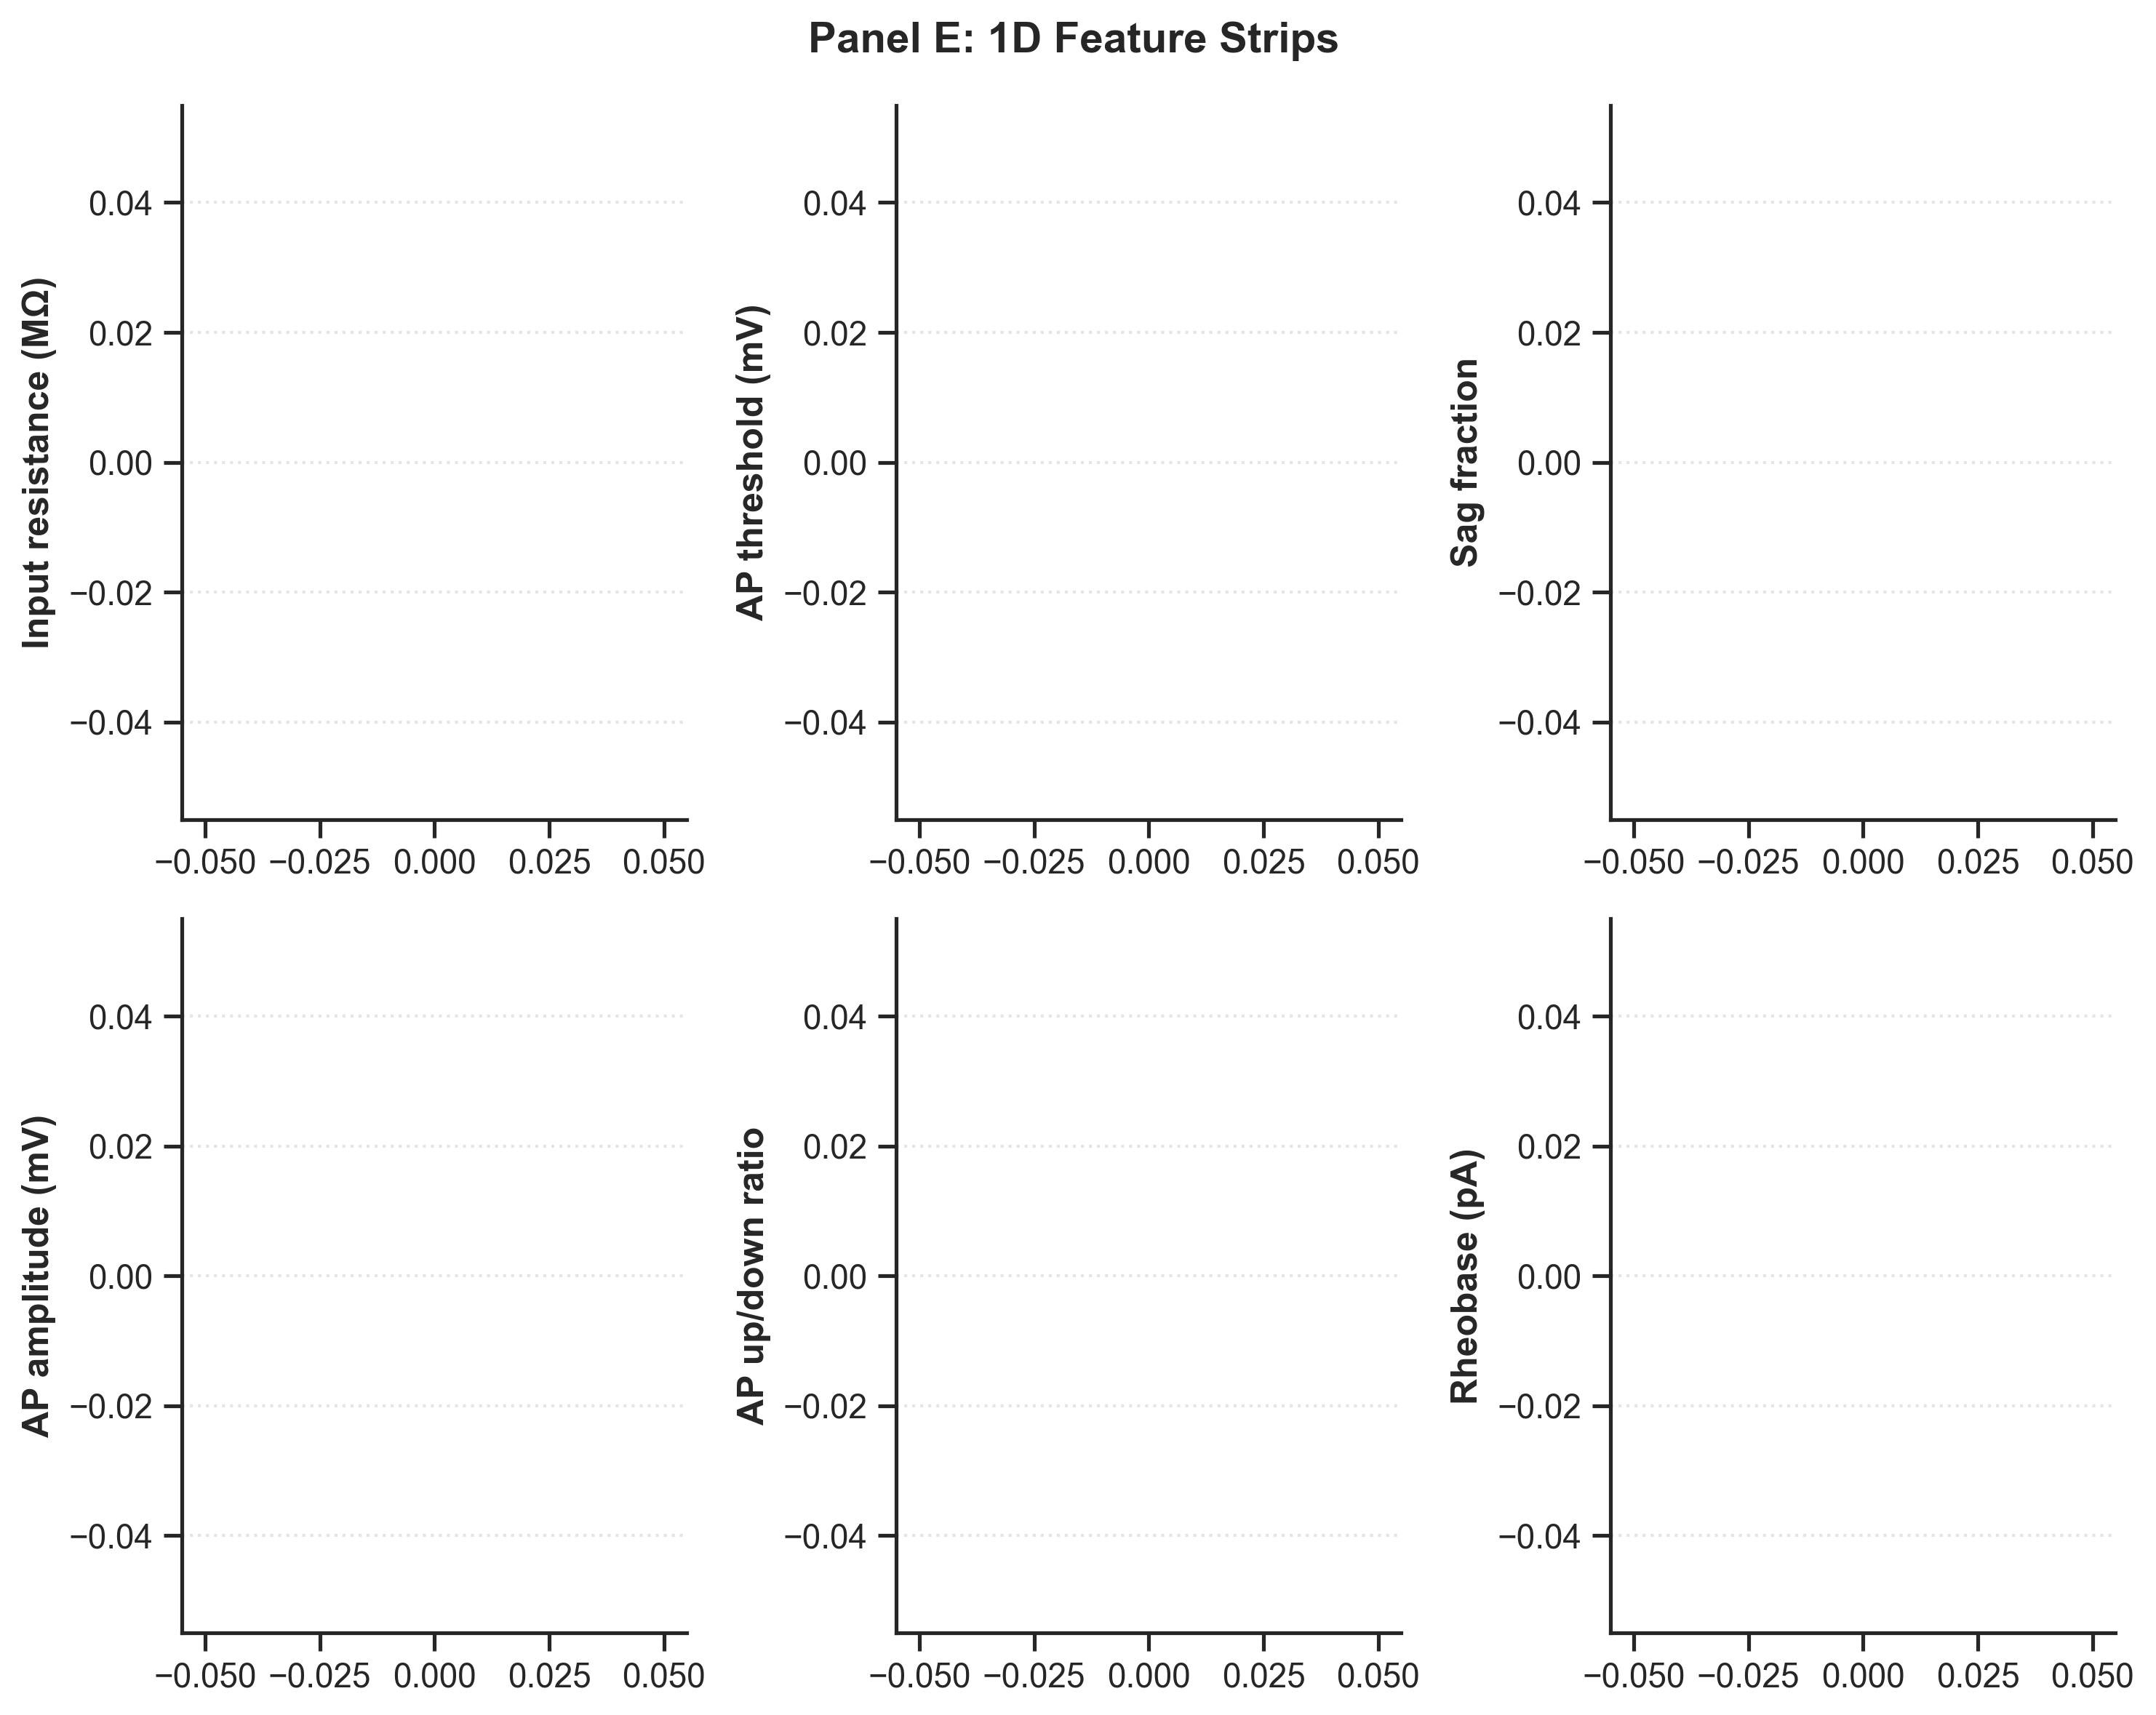

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [4]:
import os
import glob
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from scipy.signal import find_peaks
from pathlib import Path

# =============================================================================
# 1. LOAD MASTER EPHYS CSV & GOOGLE SHEET METADATA
# =============================================================================
print("📥 Loading Datasets...")
mapping_folder = r"\\allen\programs\celltypes\workgroups\hct\SamanthaL\Ephys recordings\Aipfx_mapping_SSL"
csv_files = glob.glob(os.path.join(mapping_folder, "*.csv"))
latest_csv = max(csv_files, key=os.path.getmtime)
df_master = pd.read_csv(latest_csv)

# Load Live Google Sheet for Virus, Target Cell Type, and Raw NWB Paths
sheet_url = "https://docs.google.com/spreadsheets/d/1CpN3jsWR5c84a57sGSgWtrgvnnLRKjxJgxjQg8Alx1I/export?format=csv&gid=1820785849"
df_meta = pd.read_csv(sheet_url).fillna('')
df_meta['cell_name'] = df_meta['cell_name'].astype(str).str.strip()

# Merge features with required metadata
df_merged = pd.merge(
    df_master, 
    df_meta[['cell_name', 'cell_type_targeted', 'reclassified_cell_type', 'virus', 'file_path']], 
    on='cell_name', 
    how='inner'
)

# =============================================================================
# 2. STRICT COHORT FILTERING (Ai14 MSNs vs NUDAP AiP16117)
# =============================================================================
def get_ai14_cohort(row):
    reclass = str(row.get('reclassified_cell_type', '')).strip().upper()
    target = str(row.get('cell_type_targeted', '')).strip().upper()
    ctype = reclass if (reclass and reclass != 'NAN') else target
    virus = str(row.get('virus', '')).upper()
    
    if ctype == 'EXCLUDE': return None
    if 'MSN' in ctype: return 'MSN'
    elif 'NUDAP' in ctype and 'AIP16117' in virus: return 'NUDAP'
    return None 

# Apply classification and filter for ephys_qc_pass == True & Ai14 prefix
df_merged['Cohort'] = df_merged.apply(get_ai14_cohort, axis=1)
is_valid_ai14 = (df_merged['ephys_qc_pass'] == True) & (df_merged['cell_name'].str.upper().str.startswith('AI14'))
df_plot = df_merged[is_valid_ai14].dropna(subset=['Cohort']).copy()

# Ensure we drop any rows missing the required plotting metrics
target_cols = [
    'input_resistance(mOhms)', 'rheobase_sweep_threshold_v(mV)', 
    'sag_fraction', 'rheobase_sweep_ap_amplitude(mV)', 
    'rheobase_sweep_upstroke_downstroke_ratio', 'rheobase_sweep_stim_amp(pA)'
]
df_plot = df_plot.dropna(subset=target_cols).copy()

print("=" * 60)
print(f"✅ FINAL COHORT DATASET (Total N = {len(df_plot)})")
print(df_plot['Cohort'].value_counts().to_string())
print("=" * 60)

COLORS = {'MSN': '#63C5F7', 'NUDAP': '#D717FA'} # Light blue & Magenta

# =============================================================================
# PANEL E: 6-PANEL 1D EPHYS FEATURE STRIPS
# =============================================================================
metrics = [
    {'col': 'input_resistance(mOhms)', 'title': 'Input resistance (MΩ)'},
    {'col': 'rheobase_sweep_threshold_v(mV)', 'title': 'AP threshold (mV)'},
    {'col': 'sag_fraction', 'title': 'Sag fraction'},
    {'col': 'rheobase_sweep_ap_amplitude(mV)', 'title': 'AP amplitude (mV)'},
    {'col': 'rheobase_sweep_upstroke_downstroke_ratio', 'title': 'AP up/down ratio'},
    {'col': 'rheobase_sweep_stim_amp(pA)', 'title': 'Rheobase (pA)'}
]

sns.set_theme(style="ticks")
fig_e, axes_e = plt.subplots(2, 3, figsize=(10, 8), dpi=300)
axes_e = axes_e.flatten()

for idx, cfg in enumerate(metrics):
    ax = axes_e[idx]
    m_col = cfg['col']
    
    sns.stripplot(data=df_plot, x='Cohort', y=m_col, order=['MSN', 'NUDAP'],
                  palette=COLORS, size=6, jitter=0.15, alpha=0.8, ax=ax)
    
    # Mean +/- SEM overlays (Large circle with black edge)
    stats = df_plot.groupby('Cohort')[m_col].agg(['mean', 'sem']).reindex(['MSN', 'NUDAP'])
    ax.errorbar(x=[0, 1], y=stats['mean'], yerr=stats['sem'], fmt='o',
                markerfacecolor='none', markeredgecolor='black', markeredgewidth=1.5,
                ecolor='black', elinewidth=1.5, capsize=4, markersize=10, zorder=10)
    
    ax.set_ylabel(cfg['title'], fontweight='bold')
    ax.set_xlabel("")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, axis='y', linestyle=':', alpha=0.5)

plt.suptitle("Panel E: 1D Feature Strips", fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# =============================================================================
# PANEL F: 3D FEATURE DISTRIBUTION (Sag vs Threshold vs Rin)
# =============================================================================
fig_f = go.Figure()
total_n = len(df_plot)

for cohort in ['MSN', 'NUDAP']:
    group = df_plot[df_plot['Cohort'] == cohort]
    n_group = len(group)
    c_color = COLORS[cohort]
    
    # Population Dots
    fig_f.add_trace(go.Scatter3d(
        x=group['sag_fraction'], y=group['rheobase_sweep_threshold_v(mV)'], z=group['input_resistance(mOhms)'],
        mode='markers', name=f"{cohort} | n={n_group}", text=group['cell_name'],
        marker=dict(size=8, color=c_color, opacity=0.8, line=dict(width=0))
    ))
    
    # Centroid Diamond
    mean_x, mean_y, mean_z = group['sag_fraction'].mean(), group['rheobase_sweep_threshold_v(mV)'].mean(), group['input_resistance(mOhms)'].mean()
    fig_f.add_trace(go.Scatter3d(
        x=[mean_x], y=[mean_y], z=[mean_z], mode='markers', showlegend=False,
        marker=dict(size=14, color=c_color, symbol='diamond', line=dict(color='black', width=2))
    ))

scene_dict = dict(
    bgcolor='white', camera=dict(eye=dict(x=-1.6, y=-1.6, z=0.6)),
    xaxis=dict(title="<b>Sag fraction</b>", backgroundcolor='white', showline=True, linecolor='black', linewidth=3, gridcolor='#E2E8F0', zeroline=False),
    yaxis=dict(title="<b>AP threshold (mV)</b>", backgroundcolor='white', showline=True, linecolor='black', linewidth=3, gridcolor='#E2E8F0', zeroline=False),
    zaxis=dict(title="<b>Input resistance (MΩ)</b>", backgroundcolor='white', showline=True, linecolor='black', linewidth=3, gridcolor='#E2E8F0', zeroline=False)
)

fig_f.update_layout(
    title=dict(text=f"<b>Panel F: 3D Feature Distribution | Total N={total_n}</b>", font=dict(size=16, color='#1C1C1E')),
    width=850, height=750, paper_bgcolor='white', plot_bgcolor='white', scene=scene_dict,
    legend=dict(itemsizing='constant', font=dict(size=12), bgcolor='rgba(255,255,255,0.9)')
)
fig_f.show()

# =============================================================================
# PANEL D: RAW NWB TRACES (Uses `file_path` from Google Sheet)
# =============================================================================
# SET YOUR EXEMPLARS HERE
EXEMPLAR_MSN = 'Ai14-Het-831392.01.09.01'  
EXEMPLAR_NUDAP = 'Ai14-Het-880646.03.03.06' 

target_specs = [
    {'group': 'MSN', 'query': EXEMPLAR_MSN, 'color': COLORS['MSN']},
    {'group': 'NUDAP', 'query': EXEMPLAR_NUDAP, 'color': COLORS['NUDAP']}
]

def draw_l_scalebar(ax, x_len, y_len, x_unit, y_unit, x0, y0, x_text_offset):
    ax.plot([x0, x0], [y0, y0 + y_len], color='black', lw=2.0, clip_on=False)
    ax.plot([x0, x0 + x_len], [y0, y0], color='black', lw=2.0, clip_on=False)
    ax.text(x0 - x_text_offset, y0 + (y_len / 2.0), f"{int(y_len)}{y_unit}", va='center', ha='right', fontsize=10, fontweight='bold')
    ax.text(x0 + (x_len / 2.0), y0 - (y_len * 0.25), f"{int(x_len)}{x_unit}", va='top', ha='center', fontsize=10, fontweight='bold')

fig_d = plt.figure(figsize=(10, 8), facecolor='white')
outer_grid = plt.GridSpec(1, 2, wspace=0.3)

for col_idx, spec in enumerate(target_specs):
    row_data = df_plot[df_plot['cell_name'].str.contains(spec['query'])]
    if row_data.empty:
        print(f"⚠️️ Cell {spec['query']} not found in filtered dataset.")
        continue
        
    nwb_path = os.path.normpath(row_data.iloc[0]['file_path'])
    if not os.path.exists(nwb_path):
        print(f"⚠️ Raw NWB not found at {nwb_path}")
        continue

    inner_grid = outer_grid[col_idx].subgridspec(3, 1, height_ratios=[2.5, 1.0, 1.5], hspace=0.35)
    ax_v, ax_zoom, ax_i = fig_d.add_subplot(inner_grid[0]), fig_d.add_subplot(inner_grid[1]), fig_d.add_subplot(inner_grid[2])
    ax_v.set_title(spec['group'], color=spec['color'], fontweight='bold', fontsize=14)

    with h5py.File(nwb_path, 'r') as f:
        stim_keys = [k for k in f['stimulus/presentation'].keys() if 'data' in f[f'stimulus/presentation/{k}']]
        
        for key in stim_keys:
            i_tr = f[f'stimulus/presentation/{key}/data'][:]
            v_key = key.replace("DA0", "AD0").replace("presentation", "timeseries")
            if v_key not in f['acquisition/timeseries']: continue
            v_tr = f[f'acquisition/timeseries/{v_key}/data'][:]
            
            if i_tr.ndim > 1: i_tr = i_tr[:, 0]
            if v_tr.ndim > 1: v_tr = v_tr[:, 0]
            
            i_tr = i_tr * 1e12 if np.max(np.abs(i_tr)) < 1e-3 else i_tr * 1e9
            v_tr = v_tr * 1000.0 if np.max(np.abs(v_tr)) < 1.0 else v_tr
            t = (np.arange(len(v_tr)) / 25000.0) * 1000.0
            
            base_i = np.median(i_tr[:int(len(i_tr)*0.05)])
            inj_amp = np.median(i_tr[np.abs(i_tr - base_i) > 5.0]) - base_i if len(np.where(np.abs(i_tr - base_i) > 5.0)[0]) > 0 else 0
            
            # Sub-threshold
            if -300 < inj_amp < 0:
                ax_v.plot(t, v_tr, color='gray', lw=0.5, alpha=0.5)
                ax_i.plot(t, i_tr, color='gray', lw=0.5, alpha=0.5)
            # Supra-threshold (Rheobase estimation)
            elif 0 < inj_amp < 300:
                peaks, _ = find_peaks(v_tr, height=-20)
                is_rheobase = len(peaks) > 0 and inj_amp < 150 
                color = 'black' if is_rheobase else spec['color']
                lw = 1.2 if is_rheobase else 0.5
                
                ax_v.plot(t, v_tr, color=color, lw=lw, alpha=0.8)
                ax_i.plot(t, i_tr, color=color, lw=lw, alpha=0.8)
                
                if is_rheobase and len(peaks) > 0:
                    peak_t = t[peaks[0]]
                    zoom_mask = (t >= peak_t - 5.0) & (t <= peak_t + 15.0)
                    ax_zoom.plot(t[zoom_mask] - peak_t, v_tr[zoom_mask], color='black', lw=1.5)

    ax_v.set_xlim(200, 3800); ax_v.set_ylim(-110, 60)
    ax_zoom.set_xlim(-5, 15); ax_zoom.set_ylim(-80, 60)
    ax_i.set_xlim(200, 3800); ax_i.set_ylim(-300, 400)
    
    draw_l_scalebar(ax_v, 200, 50, 'ms', 'mV', 50, -100, 50)
    draw_l_scalebar(ax_zoom, 5, 20, 'ms', 'mV', -4, -70, 1)
    draw_l_scalebar(ax_i, 200, 200, 'ms', 'pA', 50, -250, 50)
    
    for ax in [ax_v, ax_zoom, ax_i]: ax.axis('off')

plt.suptitle("Panel D: Raw NWB Traces", fontweight='bold', fontsize=14)
plt.show()

# 1. Ai14 cohort: MSN (any) and NUDAP AiP16117 fluorescent

In [2]:
import os
import glob
import re
import pandas as pd

# =============================================================================
# 1. LOAD MASTER EPHYS CSV & GOOGLE SHEET METADATA
# =============================================================================
print("📥 Loading Datasets...")
mapping_folder = r"\\allen\programs\celltypes\workgroups\hct\SamanthaL\Ephys recordings\Aipfx_mapping_SSL"
csv_files = glob.glob(os.path.join(mapping_folder, "*.csv"))
latest_csv = max(csv_files, key=os.path.getmtime)
df_master = pd.read_csv(latest_csv)

sheet_url = "https://docs.google.com/spreadsheets/d/1CpN3jsWR5c84a57sGSgWtrgvnnLRKjxJgxjQg8Alx1I/export?format=csv&gid=1820785849"
df_meta = pd.read_csv(sheet_url).fillna('')

# =============================================================================
# 2. STANDARDIZE KEYS AND MERGE
# =============================================================================
def clean_key(val):
    s = str(val).lower().strip()
    s = re.sub(r'[^\x00-\x7F]+', '', s)
    s = os.path.basename(s).replace('.nwb', '').replace('_compressed', '').replace('-compressed', '')
    return re.sub(r'_itc18usb_dev_\d+', '', s).strip()

master_cell_col = [c for c in df_master.columns if c.lower() in ['cell_name', 'target_cell', 'cell']][0]
df_master['cell_key'] = df_master[master_cell_col].apply(clean_key)
df_meta['cell_key'] = df_meta['cell_name'].apply(clean_key)

# Merge metadata
df_merged = pd.merge(
    df_master, 
    df_meta[['cell_key', 'cell_type_targeted', 'reclassified_cell_type', 'virus', 'file_path', 'fluorescent_label']], 
    on='cell_key', 
    how='inner',
    suffixes=('', '_gsheet')
)

# =============================================================================
# 3. STRICT CONDITIONAL FILTERING (MSN = All, NUDAP = AiP16117 + Fluor Pos)
# =============================================================================
def get_ai14_cohort(row):
    reclass = str(row.get('reclassified_cell_type', '')).strip().upper()
    target = str(row.get('cell_type_targeted', '')).strip().upper()
    ctype = reclass if (reclass and reclass not in ['NAN', 'NONE']) else target
    
    virus = str(row.get('virus', '')).upper()
    
    # Standardize fluorescent label
    fluor_raw = str(row.get('fluorescent_label', '')).strip().lower()
    is_fluor_pos = fluor_raw in ['yes', 'y', 'pos', 'positive', 'true', '1', '1.0']
    
    if 'EXCLUDE' in ctype: 
        return None
        
    # CONDITION 1: MSN (Any Ai14 MSN is accepted)
    if 'MSN' in ctype: 
        return 'MSN'
        
    # CONDITION 2: NUDAP (Requires AiP16117 AND Fluorescent Positive)
    elif 'NUDAP' in ctype and 'AIP16117' in virus and is_fluor_pos: 
        return 'NUDAP'
        
    return None 

df_merged['Cohort'] = df_merged.apply(get_ai14_cohort, axis=1)

# Filter: QC Pass + Ai14 + Valid Cohort assignment
is_valid_ai14 = (df_merged['ephys_qc_pass'] == True) & (df_merged['cell_key'].str.startswith('ai14'))

df_plot = df_merged[is_valid_ai14].dropna(subset=['Cohort']).copy()

# Ensure we drop any rows missing the required plotting metrics
target_cols = [
    'input_resistance(mOhms)', 'rheobase_sweep_threshold_v(mV)', 
    'sag_fraction', 'rheobase_sweep_ap_amplitude(mV)', 
    'rheobase_sweep_upstroke_downstroke_ratio', 'rheobase_sweep_stim_amp(pA)'
]
df_plot = df_plot.dropna(subset=target_cols).copy()

# =============================================================================
# 4. PRINT ITEMIZED AUDIT LIST
# =============================================================================
print("=" * 80)
print(f"✅ FINAL PLOTTING DATASET (Total N = {len(df_plot)})")
print("=" * 80)

for cohort in ['MSN', 'NUDAP']:
    group = df_plot[df_plot['Cohort'] == cohort]
    print(f"\n📌 {cohort} (n={len(group)}):")
    for idx, row in group.reset_index(drop=True).iterrows():
        cell_val = row[master_cell_col]
        virus_val = row['virus']
        fluor_val = row['fluorescent_label']
        print(f"  {idx+1:>2d}. {cell_val:<35} | Fluor: {fluor_val:<4} | Virus: {virus_val}")

📥 Loading Datasets...
✅ FINAL PLOTTING DATASET (Total N = 44)

📌 MSN (n=18):
   1. Ai14-Het-817118.01.01.01            | Fluor: no   | Virus: AiP15019
   2. Ai14-Het-826949.01.09.02            | Fluor: no   | Virus: AiP15019
   3. Ai14-Het-826951.01.09.01            | Fluor: no   | Virus: AiP15019
   4. Ai14-Het-826951.02.09.03            | Fluor: no   | Virus: AiP15019
   5. Ai14-Het-831392.01.09.02            | Fluor: no   | Virus: AiP15019
   6. Ai14-Het-831390.02.09.01            | Fluor: no   | Virus: AiP15019
   7. Ai14-Het-870321.01.09.01            | Fluor: no   | Virus: AiP16117
   8. Ai14-Het-870324.02.09.03            | Fluor: no   | Virus: AiP16117
   9. Ai14-Het-874569.02.09.01            | Fluor: no   | Virus: AiP16117
  10. Ai14-Het-874571.01.09.02            | Fluor: no   | Virus: AiP15019
  11. Ai14-Het-876009.01.09.02            | Fluor: no   | Virus: AiP15019
  12. Ai14-Het-874572.01.09.04            | Fluor: no   | Virus: AiP15019
  13. Ai14-Het-876010.01.09.05     

# 2. 6 panel ephys plot

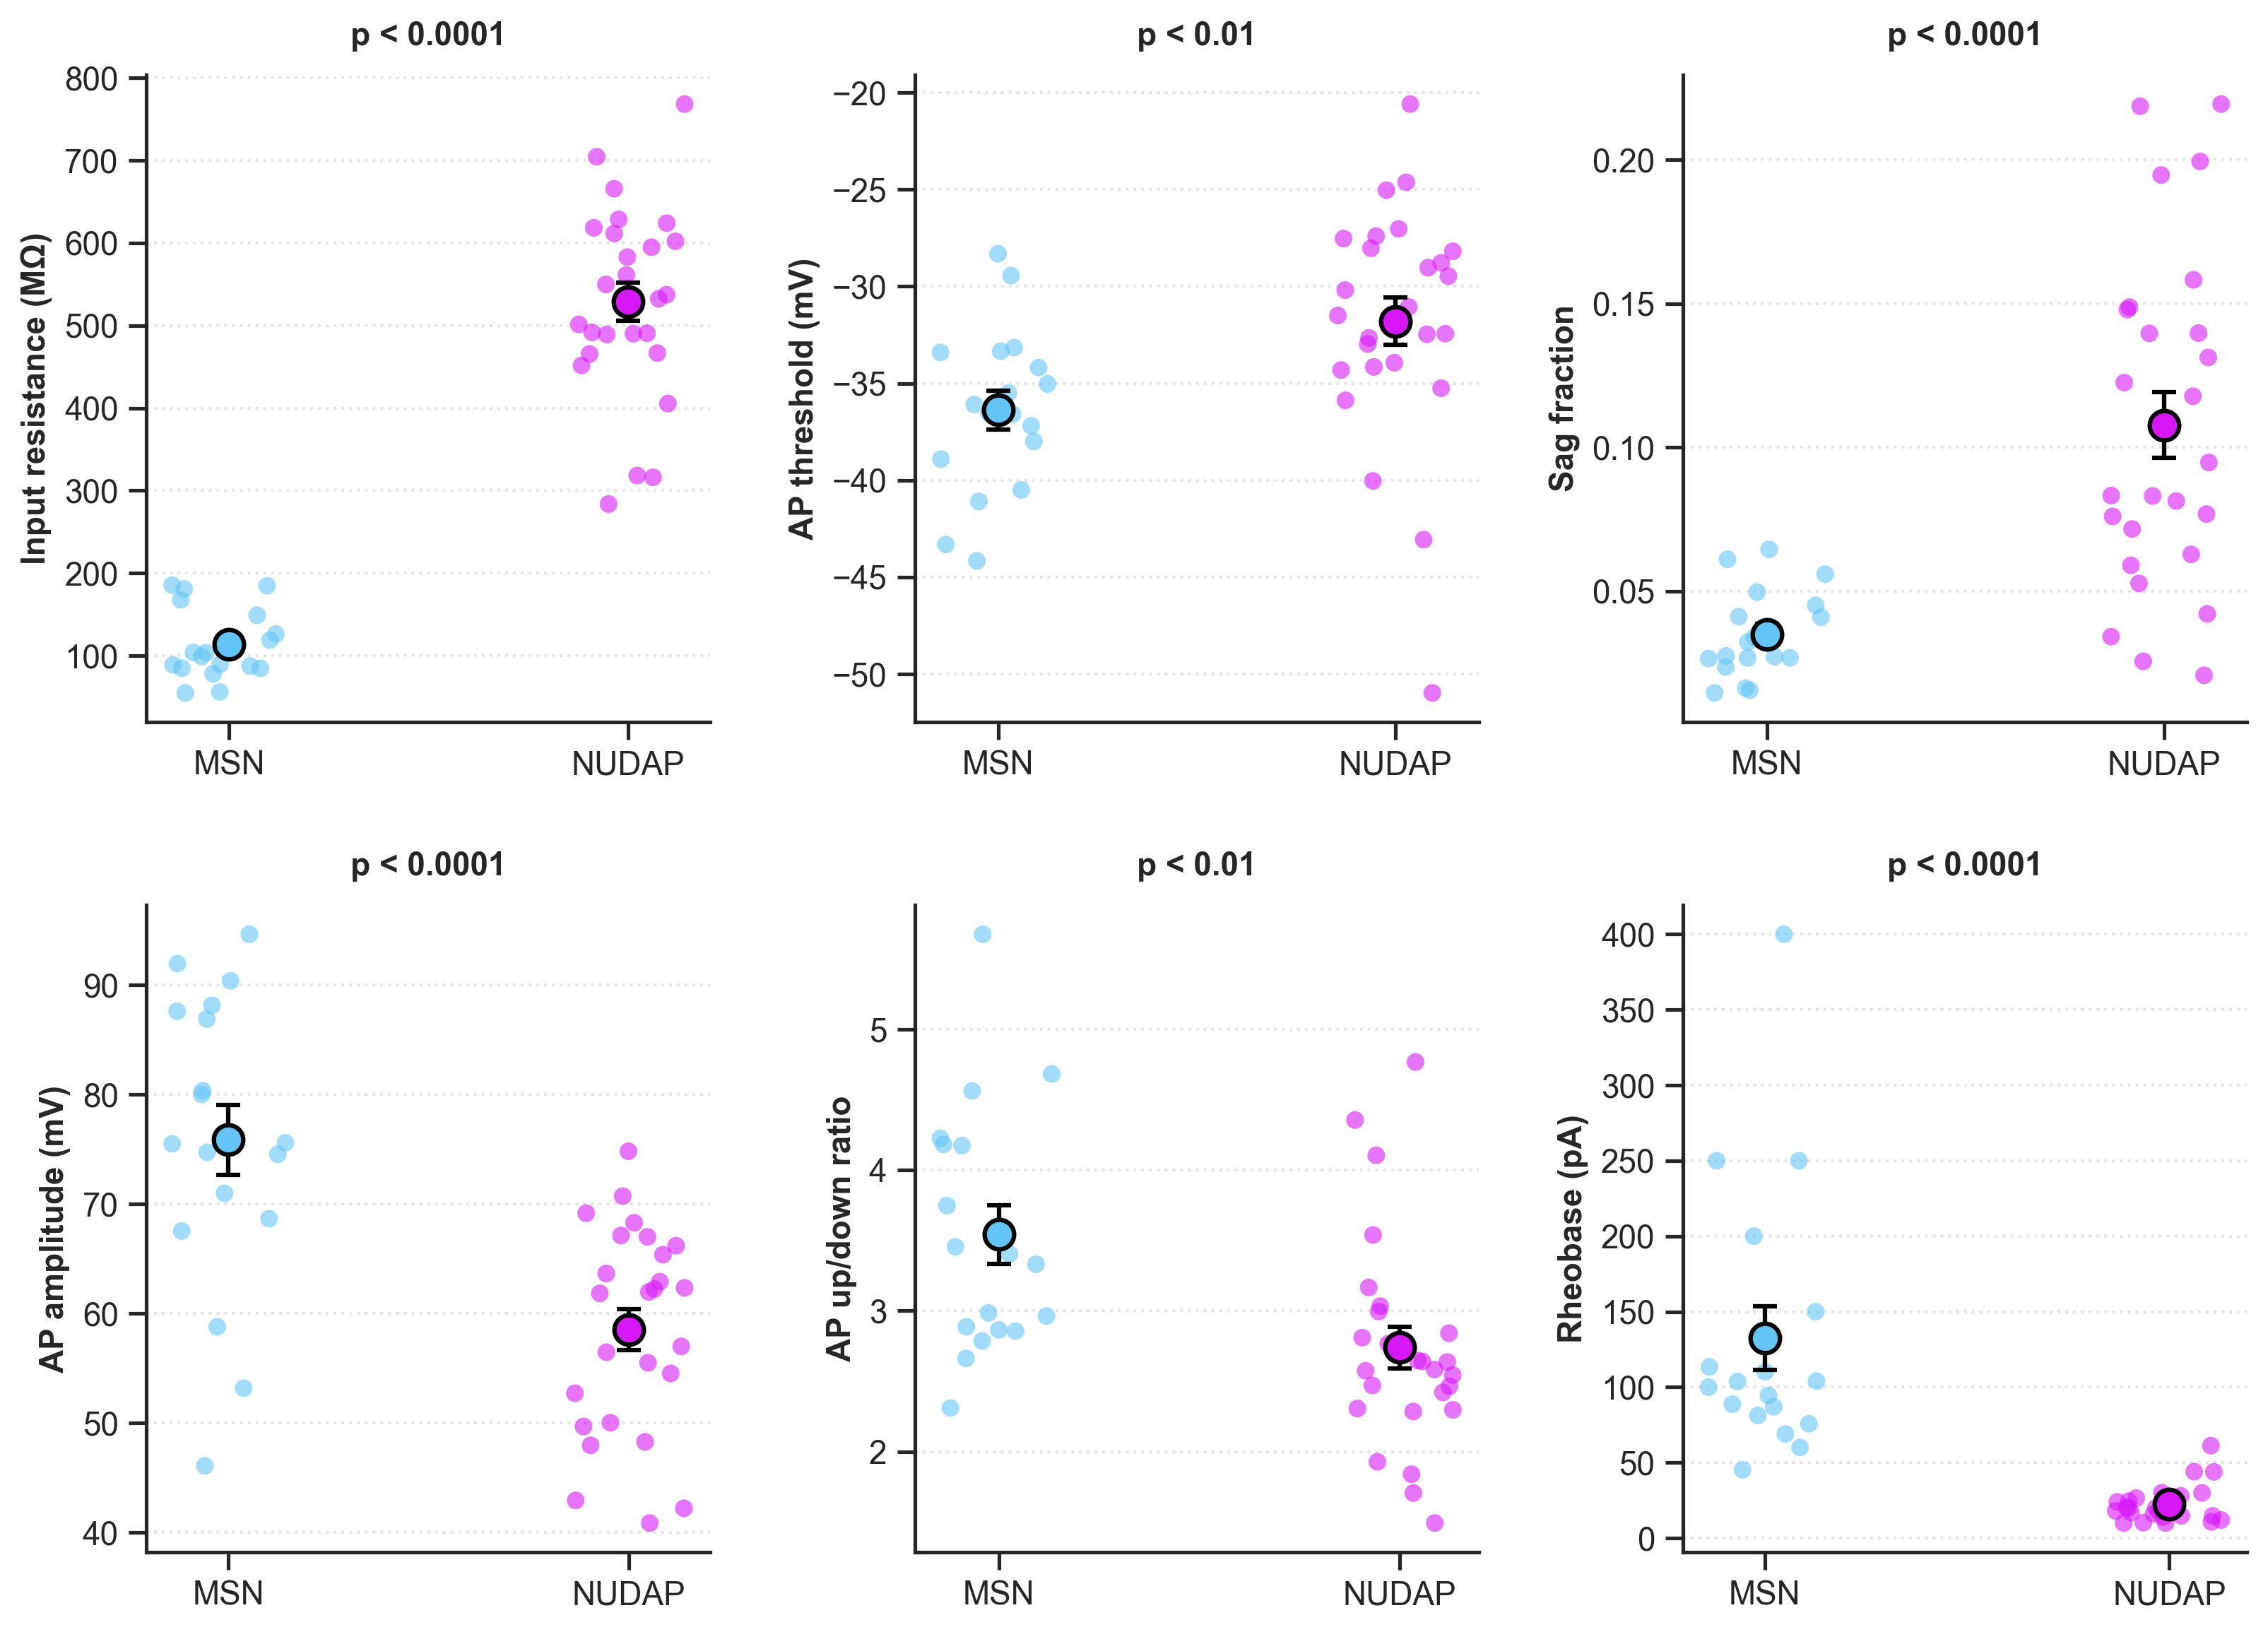

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

# Cohort colors matching your figure
COLORS = {'MSN': '#63C5F7', 'NUDAP': '#D717FA'} 

# =============================================================================
# 1D EPHYS FEATURE STRIPS (PANEL E)
# =============================================================================
metrics = [
    {'col': 'input_resistance(mOhms)', 'title': 'Input resistance (MΩ)'},
    {'col': 'rheobase_sweep_threshold_v(mV)', 'title': 'AP threshold (mV)'},
    {'col': 'sag_fraction', 'title': 'Sag fraction'},
    {'col': 'rheobase_sweep_ap_amplitude(mV)', 'title': 'AP amplitude (mV)'},
    {'col': 'rheobase_sweep_upstroke_downstroke_ratio', 'title': 'AP up/down ratio'},
    {'col': 'rheobase_sweep_stim_amp(pA)', 'title': 'Rheobase (pA)'}
]

sns.set_theme(style="ticks")
# Slightly wider figure (11x8) to give horizontal labels more space
fig, axes = plt.subplots(2, 3, figsize=(11, 8), dpi=300)
axes = axes.flatten()

for idx, cfg in enumerate(metrics):
    ax = axes[idx]
    m_col = cfg['col']
    
    # 1. Jittered strip plot (Fixed the hue/legend warning, slightly reduced alpha so means pop)
    sns.stripplot(data=df_plot, x='Cohort', y=m_col, hue='Cohort', order=['MSN', 'NUDAP'],
                  palette=COLORS, size=6, jitter=0.15, alpha=0.6, ax=ax, legend=False)
    
    # 2. Mean +/- SEM overlays (Filled with cohort color, black borders)
    stats = df_plot.groupby('Cohort')[m_col].agg(['mean', 'sem']).reindex(['MSN', 'NUDAP'])
    for i, cohort in enumerate(['MSN', 'NUDAP']):
        ax.errorbar(x=i, y=stats.loc[cohort, 'mean'], yerr=stats.loc[cohort, 'sem'], fmt='o',
                    markerfacecolor=COLORS[cohort], markeredgecolor='black', markeredgewidth=1.5,
                    ecolor='black', elinewidth=1.5, capsize=4, markersize=10, zorder=10)
    
    # 3. Statistical Test (Mann-Whitney U)
    msn_data = df_plot[df_plot['Cohort'] == 'MSN'][m_col].dropna()
    nudap_data = df_plot[df_plot['Cohort'] == 'NUDAP'][m_col].dropna()
    
    if len(msn_data) > 0 and len(nudap_data) > 0:
        stat, pval = mannwhitneyu(msn_data, nudap_data)
        if pval < 0.0001:
            p_text = "p < 0.0001"
        elif pval < 0.001:
            p_text = "p < 0.001"
        elif pval < 0.01:
            p_text = "p < 0.01"
        elif pval < 0.05:
            p_text = "p < 0.05"
        else:
            p_text = "ns"
        ax.set_title(p_text, fontsize=11, fontweight='bold', pad=10)
    
    # 4. Formatting
    ax.set_ylabel(cfg['title'], fontweight='bold', fontsize=11)
    ax.set_xlabel("")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', labelsize=11)
    ax.grid(True, axis='y', linestyle=':', alpha=0.5)

# Added w_pad and h_pad to prevent titles and y-labels from overlapping
plt.tight_layout(pad=1.5, w_pad=2.0, h_pad=2.0)
plt.show()

# 3. save CSV for cohort

In [12]:
import os
from datetime import datetime

# Define the output directory (using your established cohort folder)
output_folder = r"\\allen\programs\celltypes\workgroups\hct\SamanthaL\Ephys recordings\Aipfx_Ai14_MSN_NUDAP_AiP16117"

os.makedirs(output_folder, exist_ok=True)

# Generate a timestamp for version control
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
file_name = f"Ai14_MSN_NUDAP_AiP16117_ephys_features_{timestamp}.csv"
output_csv = os.path.join(output_folder, file_name)

# Export the fully merged and filtered dataset
df_plot.to_csv(output_csv, index=False)

print("=" * 80)
print(f"✅ Saved final cohort dataset (Total N = {len(df_plot)})")
print(f"📂 Path: {output_csv}")
print("=" * 80)

✅ Saved final cohort dataset (Total N = 44)
📂 Path: \\allen\programs\celltypes\workgroups\hct\SamanthaL\Ephys recordings\Aipfx_Ai14_MSN_NUDAP_AiP16117\Ai14_MSN_NUDAP_AiP16117_ephys_features_20261004_184524.csv


# 4. 3d plot

In [ ]:
# Ai14-Het-880646.03.03.06

In [42]:
#v2
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# =========================================================================
# 1. DEFINE YOUR EXAMPLE CELLS
# =========================================================================
EXAMPLE_MSN = "Ai14-Het-817118.01.01.01"  
EXAMPLE_NUDAP = "Ai14-Het-880646.03.03.06"

COLORS = {'MSN': '#63C5F7', 'NUDAP': '#D717FA'}
DOT_SIZE = 8  # Base dot size for all points

# Feature column mappings
x_col = 'rheobase_sweep_threshold_v(mV)'  # AP threshold (mV)
y_col = 'sag_fraction'                    # Sag fraction
z_col = 'input_resistance(mOhms)'         # Input resistance (MΩ)

fig = go.Figure()

# =========================================================================
# 2. MAIN CLUSTER POINTS
# =========================================================================
for cohort, color in COLORS.items():
    df_cohort = df_plot[df_plot['Cohort'] == cohort]
    
    fig.add_trace(go.Scatter3d(
        x=df_cohort[x_col],
        y=df_cohort[y_col],
        z=df_cohort[z_col],
        mode='markers',
        name=cohort,
        text=df_cohort['cell_name'],
        hoverinfo='text+x+y+z',
        marker=dict(
            size=DOT_SIZE,
            color=color,
            opacity=0.85
        )
    ))

# =========================================================================
# 3. OVERLAY HIGHLIGHTED EXAMPLE CELLS (DOUBLE-LAYER FOR BOLD OUTLINE)
# =========================================================================
example_cells = [
    (EXAMPLE_MSN, 'MSN', COLORS['MSN']),
    (EXAMPLE_NUDAP, 'NUDAP', COLORS['NUDAP'])
]

for cell_name, cohort, color in example_cells:
    ex_data = df_plot[df_plot['cell_name'].str.contains(cell_name, case=False, na=False)]
    
    if not ex_data.empty:
        row = ex_data.iloc[0]
        matched_name = row['cell_name']
        
        # Layer 1: Solid black backing dot (guarantees a thick 3D border)
        fig.add_trace(go.Scatter3d(
            x=[row[x_col]],
            y=[row[y_col]],
            z=[row[z_col]],
            mode='markers',
            showlegend=False,
            hoverinfo='none',
            marker=dict(
                size=DOT_SIZE + 2,  # Slightly larger black backing dot
                color='black',
                opacity=1.0
            )
        ))
        
        # Layer 2: Colored inner dot with explicit legend annotation
        fig.add_trace(go.Scatter3d(
            x=[row[x_col]],
            y=[row[y_col]],
            z=[row[z_col]],
            mode='markers',
            name=f"Example {cohort} ({matched_name})",
            text=[f"EXAMPLE {cohort}: {matched_name}"],
            hoverinfo='text',
            showlegend=True,  # Shows up directly in the legend
            marker=dict(
                size=DOT_SIZE,
                color=color,
                opacity=1.0,
                line=dict(color='black', width=4)
            )
        ))
    else:
        print(f"⚠️ Warning: Example cell '{cell_name}' not found in dataframe!")

# =========================================================================
# 4. PUBLICATION AXES & CLEAN LEGEND (NO BOX OUTLINE)
# =========================================================================
axis_style = dict(
    showbackground=False,
    showline=True,
    linecolor='black',
    linewidth=4,
    gridcolor='#E5E5E5',
    gridwidth=1,
    showgrid=True,
    zeroline=False,
    tickfont=dict(size=11, color='black', family='Arial'),
    title_font=dict(size=13, color='black', family='Arial')
)

fig.update_layout(
    scene=dict(
        xaxis=dict(title='<b>AP threshold (mV)</b>', **axis_style),
        yaxis=dict(title='<b>Sag fraction</b>', **axis_style),
        zaxis=dict(title='<b>Input resistance (MΩ)</b>', **axis_style),
        aspectmode='cube',
        camera=dict(
            eye=dict(x=1.6, y=-1.6, z=1.2)
        )
    ),
    paper_bgcolor='white',
    plot_bgcolor='white',
    margin=dict(l=10, r=10, b=10, t=10),
    legend=dict(
        x=0.70, 
        y=0.90, 
        font=dict(size=11, family="Arial", color="black"),
        bgcolor='rgba(255,255,255,0.0)',  # Completely transparent legend background
        bordercolor=None,                   # Removes legend outer frame
        borderwidth=0
    )
)

fig.show()

In [ ]:
import plotly.graph_objects as go

# =========================================================================
# 1. SETTINGS & SIZES
# =========================================================================
CUSTOM_COLORS = {'MSN': '#63C5F7', 'NUDAP': '#D717FA'}
EXEMPLAR_IDS = ['831392.01.09.01', '880646.03.03.06']

UNIFORM_SIZE = 8       # All shapes (circles, exemplars, diamonds) rendered at size 8
OUTLINE_SIZE = 11.5    # Outer black shell for exemplar circles only

# =========================================================================
# 2. BUILD 3D FIGURE (PANEL F)
# =========================================================================
fig = go.Figure()
total_n = len(df_plot)

for cohort in ['MSN', 'NUDAP']:
    group = df_plot[df_plot['Cohort'] == cohort]
    color = CUSTOM_COLORS[cohort]
    n_group = len(group)

    # Separate Exemplars from the rest of the population
    is_ex = group['cell_name'].astype(str).apply(lambda name: any(ex in name for ex in EXEMPLAR_IDS))
    non_ex = group[~is_ex]
    ex = group[is_ex]

    # A. Standard Population Scatter Points (Circles, size=8)
    fig.add_trace(go.Scatter3d(
        x=non_ex['sag_fraction'], 
        y=non_ex['rheobase_sweep_threshold_v(mV)'], 
        z=non_ex['input_resistance(mOhms)'],
        mode='markers', 
        name=f"{cohort} (n={n_group})", 
        text=non_ex['cell_name'],
        marker=dict(size=UNIFORM_SIZE, color=color, opacity=0.8, line=dict(color=color, width=0))
    ))

    # B. Exemplar Cells ONLY (Black outer ring + Inner core, size=8)
    if not ex.empty:
        # 1st trace: Black outer shell
        fig.add_trace(go.Scatter3d(
            x=ex['sag_fraction'], y=ex['rheobase_sweep_threshold_v(mV)'], z=ex['input_resistance(mOhms)'],
            mode='markers', showlegend=False, hoverinfo='skip',
            marker=dict(size=OUTLINE_SIZE, color='black', symbol='circle', opacity=1.0)
        ))
        # 2nd trace: Inner colored core
        fig.add_trace(go.Scatter3d(
            x=ex['sag_fraction'], y=ex['rheobase_sweep_threshold_v(mV)'], z=ex['input_resistance(mOhms)'],
            mode='markers', name=f"{cohort} Exemplar",
            text=ex['cell_name'].apply(lambda c: f"Exemplar Trace: {c}"),
            marker=dict(size=UNIFORM_SIZE, color=color, symbol='circle', opacity=1.0)
        ))

    # C. Group Mean Centroids (Diamonds, size=8, NO BLACK BORDER)
    mean_x = group['sag_fraction'].mean()
    mean_y = group['rheobase_sweep_threshold_v(mV)'].mean()
    mean_z = group['input_resistance(mOhms)'].mean()

    fig.add_trace(go.Scatter3d(
        x=[mean_x], y=[mean_y], z=[mean_z],
        mode='markers', name=f"{cohort} Centroid",
        text=[f"{cohort} Mean (Sag={mean_x:.2f}, Thresh={mean_y:.1f}mV, Rin={mean_z:.1f}MΩ)"],
        marker=dict(size=UNIFORM_SIZE, color=color, symbol='diamond', opacity=1.0, line=dict(width=0))
    ))

# =========================================================================
# 3. PURE WHITE LAYOUT & FORMATTING
# =========================================================================
scene_dict = dict(
    bgcolor='#FFFFFF',
    camera=dict(eye=dict(x=-1.6, y=-1.6, z=0.8)),
    xaxis=dict(title="<b>Sag fraction</b>", backgroundcolor='#FFFFFF', showline=True, linecolor='#000000', linewidth=4, zeroline=False, gridcolor='#E2E8F0'),
    yaxis=dict(title="<b>AP threshold (mV)</b>", backgroundcolor='#FFFFFF', showline=True, linecolor='#000000', linewidth=4, zeroline=False, gridcolor='#E2E8F0'),
    zaxis=dict(title="<b>Input resistance (MΩ)</b>", backgroundcolor='#FFFFFF', showline=True, linecolor='#000000', linewidth=4, zeroline=False, gridcolor='#E2E8F0')
)

fig.update_layout(
    title=dict(text=f"<b>Panel F: 3D Feature Distribution (MSN vs NUDAP AiP16117) | Total N={total_n}</b>", font=dict(size=16, color='#1C1C1E')), 
    width=950, height=800, paper_bgcolor='#FFFFFF', plot_bgcolor='#FFFFFF', scene=scene_dict,
    legend=dict(itemsizing='constant', font=dict(size=11), bgcolor='rgba(255,255,255,0.9)', bordercolor='#CCCCCC', borderwidth=1)
)

fig.show()

# 5. VI FI traces

In [34]:
#v2
import os
import re
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import find_peaks
from matplotlib.backends.backend_pdf import PdfPages
from datetime import datetime

# =========================================================================
# 1. OUTPUT SETTINGS
# =========================================================================
output_folder = r"\\allen\programs\celltypes\workgroups\hct\SamanthaL\Ephys recordings\Aipfx_Ai14_MSN_NUDAP_AiP16117"
os.makedirs(output_folder, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_pdf = os.path.join(output_folder, f"Ai14_MSN_NUDAP_AiP16117_traces_{timestamp}.pdf")

COLORS = {'MSN': '#63C5F7', 'NUDAP': '#D717FA'}
BOX_TEXT_COLORS = {'MSN': '#1A237E', 'NUDAP': '#880E4F'} 

valid_cells = df_plot['cell_name'].unique().tolist()
print(f"📄 Generating publication PDF for {len(valid_cells)} cells across {int(np.ceil(len(valid_cells)/4))} pages...")

# Helper to safely retrieve metadata fields without crashing on missing/NaN values
def get_meta(row, key, default="N/A"):
    if key in row and pd.notna(row[key]):
        val = str(row[key]).strip()
        return val if val != "" else default
    return default

def draw_l_scalebar(ax, x_len, y_len, x_unit, y_unit, x0, y0, x_text_offset):
    ax.plot([x0, x0], [y0, y0 + y_len], color='black', lw=2.0, clip_on=False)
    ax.plot([x0, x0 + x_len], [y0, y0], color='black', lw=2.0, clip_on=False)
    ax.text(x0 - x_text_offset, y0 + (y_len / 2.0), f"{int(y_len)}{y_unit}", va='center', ha='right', fontsize=9, fontweight='bold')
    ax.text(x0 + (x_len / 2.0), y0 - (y_len * 0.25), f"{int(x_len)}{x_unit}", va='top', ha='center', fontsize=9, fontweight='bold')

# =========================================================================
# 2. MULTI-PAGE PDF GENERATION LOOP
# =========================================================================
with PdfPages(output_pdf) as pdf:
    for i in range(0, len(valid_cells), 4):
        fig = plt.figure(figsize=(11, 13.5), facecolor='white')
        outer_grid = gridspec.GridSpec(2, 2, wspace=0.35, hspace=0.55, left=0.10, right=0.95, top=0.92, bottom=0.08)

        for j in range(4):
            if i + j >= len(valid_cells): continue
            
            row_idx, col_idx = j // 2, j % 2
            cell_name = valid_cells[i + j]
            cell_data = df_plot[df_plot['cell_name'] == cell_name].iloc[0]
            
            cohort = cell_data['Cohort']
            c_color = COLORS[cohort]
            t_color = BOX_TEXT_COLORS[cohort]
            nwb_path = os.path.normpath(cell_data['file_path'])
            panel_letter = chr(65 + j)
            
            # Retrieve metadata
            rec_date = get_meta(cell_data, 'date')
            container = get_meta(cell_data, 'patched_cell_container')
            subclass = get_meta(cell_data, 'best.subclass_label')

            inner_grid = outer_grid[row_idx, col_idx].subgridspec(3, 1, height_ratios=[2.5, 1.0, 1.5], hspace=0.35)
            ax_v = fig.add_subplot(inner_grid[0])
            ax_zoom = fig.add_subplot(inner_grid[1])
            ax_i = fig.add_subplot(inner_grid[2])
            
            # Headers & Metadata Banner
            ax_v.text(0.5, 1.25, f"   {cohort}   ", transform=ax_v.transAxes, fontsize=11, fontweight='bold', ha='center', va='center', color=t_color, bbox=dict(boxstyle='square,pad=0.5', facecolor='white', edgecolor='#333333', lw=1.2))
            ax_v.text(-0.08, 1.05, panel_letter, transform=ax_v.transAxes, fontsize=15, fontweight='black', ha='right', va='bottom')
            
            # Multi-line cell label under current plot
            meta_label = f"{cell_name}\nDate: {rec_date} | Container: {container}\nSubclass: {subclass}"
            ax_i.text(0.5, -0.45, meta_label, transform=ax_i.transAxes, fontsize=8, fontweight='bold', ha='center', va='top', color='#222222', linespacing=1.3)
            
            for ax in [ax_v, ax_zoom, ax_i]:
                ax.axis('off')
                ax.set_facecolor('white')

            if not os.path.exists(nwb_path):
                ax_v.text(0.5, 0.5, "Raw NWB File Not Found", ha='center', va='center', transform=ax_v.transAxes)
                continue

            sweep_family = {}
            
            try:
                with h5py.File(nwb_path, 'r') as f:
                    stim_group = f['stimulus/presentation']
                    
                    def get_sweep_num(k):
                        match = re.search(r'\d+', k)
                        return int(match.group()) if match else -1
                    
                    stim_keys = sorted([k for k in stim_group.keys() if 'data' in stim_group[k]], key=get_sweep_num)
                    
                    for key in stim_keys:
                        stim_desc = ""
                        if 'stimulus_description' in stim_group[key].attrs:
                            val = stim_group[key].attrs['stimulus_description']
                            stim_desc = val.decode('utf-8', errors='ignore') if isinstance(val, bytes) else str(val)
                        elif 'stimulus_description' in stim_group[key]:
                            val = stim_group[key]['stimulus_description'][()]
                            stim_desc = val.decode('utf-8', errors='ignore') if isinstance(val, bytes) else str(val)
                            
                        desc_lower = stim_desc.lower()
                        
                        if any(x in desc_lower for x in ['ramp', 'chirp', 'zap', 'short', 'sp_', 'noise', 'vc']):
                            continue

                        v_path = None
                        v_key_1 = key.replace("DA0", "AD0").replace("presentation", "timeseries")
                        match = re.search(r'\d+', key)
                        
                        if f'acquisition/timeseries/{v_key_1}/data' in f:
                            v_path = f'acquisition/timeseries/{v_key_1}/data'
                        elif match and f'acquisition/Sweep_{int(match.group())}/data' in f:
                            v_path = f'acquisition/Sweep_{int(match.group())}/data'
                        elif match and f'acquisition/data_{int(match.group()):05d}_AD0/data' in f:
                            v_path = f'acquisition/data_{int(match.group()):05d}_AD0/data'
                            
                        if not v_path: continue

                        i_raw = stim_group[f'{key}/data'][:]
                        v_raw = f[v_path][:]
                        
                        if not np.issubdtype(i_raw.dtype, np.number) or not np.issubdtype(v_raw.dtype, np.number):
                            continue
                            
                        i_tr = i_raw.astype(float)
                        v_tr = v_raw.astype(float)

                        if i_tr.ndim > 1: i_tr = i_tr[:, 0]
                        if v_tr.ndim > 1: v_tr = v_tr[:, 0]
                        
                        i_tr = i_tr[~np.isnan(i_tr)]
                        v_tr = v_tr[~np.isnan(v_tr)]
                        if len(v_tr) == 0 or len(i_tr) == 0: continue
                        
                        min_len = min(len(i_tr), len(v_tr))
                        i_tr, v_tr = i_tr[:min_len], v_tr[:min_len]

                        max_i = np.max(np.abs(i_tr))
                        if max_i < 1e-6: i_tr = i_tr * 1e12 
                        elif max_i < 1e-3: i_tr = i_tr * 1e9   
                        
                        max_v = np.max(np.abs(v_tr))
                        if max_v < 1.0: v_tr = v_tr * 1000.0 
                            
                        if np.max(v_tr) > 100 or np.min(v_tr) < -150:
                            continue
                            
                        t = (np.arange(len(v_tr)) / 25000.0) * 1000.0
                        
                        base_i = np.median(i_tr[:int(len(i_tr)*0.05)])
                        active_idx = np.where(np.abs(i_tr - base_i) > 5.0)[0]
                        
                        if len(active_idx) < 10000: 
                            continue
                            
                        inj_amp = int(np.round(np.median(i_tr[active_idx]) - base_i))
                        peaks, _ = find_peaks(v_tr, height=-20)
                        
                        sweep_family[inj_amp] = {
                            'v_tr': v_tr, 'i_tr': i_tr, 't': t,
                            'has_spike': len(peaks) > 0, 'peaks': peaks
                        }

                # --- RHEOBASE SELECTION & PLOTTING ---
                if sweep_family:
                    spiking_amps = sorted([amp for amp, data in sweep_family.items() if data['has_spike'] and amp > 0])
                    
                    if not spiking_amps:
                        kept_amps = [amp for amp in sweep_family.keys() if amp <= 0]
                        rheo_amp = None
                    else:
                        rheo_amp = spiking_amps[0]
                        pos_amps = sorted([amp for amp in sweep_family.keys() if amp > 0])
                        rheo_idx = pos_amps.index(rheo_amp)
                        max_allowed_amp = pos_amps[rheo_idx + 1] if rheo_idx + 1 < len(pos_amps) else rheo_amp
                        kept_amps = [amp for amp in sweep_family.keys() if amp <= max_allowed_amp]
                    
                    if kept_amps:
                        max_pA = max(kept_amps)
                        min_pA = min([amp for amp in kept_amps if amp < 0] + [0])
                        
                        for amp in kept_amps:
                            data = sweep_family[amp]
                            is_rheo = (amp == rheo_amp)
                            
                            line_color = '#000000' if is_rheo else c_color
                            z_order = 10 if is_rheo else 2
                            l_width = 1.3 if is_rheo else 0.65
                            
                            ax_v.plot(data['t'], data['v_tr'], color=line_color, lw=l_width, zorder=z_order, alpha=0.9)
                            ax_i.plot(data['t'], data['i_tr'], color=line_color, lw=l_width, zorder=z_order, alpha=0.9)
                            
                            if is_rheo and len(data['peaks']) > 0:
                                peak_t = data['t'][data['peaks'][0]]
                                zoom_mask = (data['t'] >= peak_t - 5.0) & (data['t'] <= peak_t + 15.0)
                                ax_zoom.plot(data['t'][zoom_mask] - peak_t, data['v_tr'][zoom_mask], color='#000000', lw=1.5)

                        ax_v.set_xlim(200, 3800)
                        ax_v.set_ylim(-110, 65)
                        draw_l_scalebar(ax_v, x_len=200, y_len=50, x_unit='ms', y_unit='mV', x0=50, y0=-105, x_text_offset=60)

                        ax_zoom.set_xlim(-5, 15)
                        ax_zoom.set_ylim(-80, 65)
                        draw_l_scalebar(ax_zoom, x_len=5, y_len=20, x_unit='ms', y_unit='mV', x0=-4, y0=-70, x_text_offset=1)

                        ax_i.set_xlim(200, 3800)
                        ax_i.set_ylim(-300, max(max_pA + 100, 200))
                        draw_l_scalebar(ax_i, x_len=500, y_len=200, x_unit='ms', y_unit='pA', x0=0, y0=-250, x_text_offset=60)

                        ax_i.text(1800, max_pA + 20, f"{max_pA} pA", ha='center', va='bottom', fontsize=9, fontweight='bold', color=c_color)
                        if min_pA < 0:
                            ax_i.text(1800, min_pA - 20, f"{min_pA} pA", ha='center', va='top', fontsize=9, fontweight='bold', color=c_color)

            except Exception as e:
                print(f"⚠️ Error plotting {cell_name}: {e}")

        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)
        print(f"✅ Page {i//4 + 1} generated...")

print("=" * 65)
print(f"🎉 Complete! PDF saved to:\n{output_pdf}")
print("=" * 65)

📄 Generating publication PDF for 44 cells across 11 pages...
✅ Page 1 generated...
✅ Page 2 generated...
✅ Page 3 generated...
✅ Page 4 generated...
✅ Page 5 generated...
✅ Page 6 generated...
✅ Page 7 generated...
✅ Page 8 generated...
✅ Page 9 generated...
✅ Page 10 generated...
✅ Page 11 generated...
🎉 Complete! PDF saved to:
\\allen\programs\celltypes\workgroups\hct\SamanthaL\Ephys recordings\Aipfx_Ai14_MSN_NUDAP_AiP16117\Ai14_MSN_NUDAP_AiP16117_traces_20261004_215437.pdf


In [5]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import find_peaks
from matplotlib.backends.backend_pdf import PdfPages
from datetime import datetime

# =========================================================================
# 1. SETTINGS & STYLING
# =========================================================================
output_folder = r"\\allen\programs\celltypes\workgroups\hct\SamanthaL\Ephys recordings\Aipfx_Ai14_MSN_NUDAP_AiP16117"
os.makedirs(output_folder, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_pdf = os.path.join(output_folder, f"Ai14_MSN_NUDAP_AiP16117_traces_{timestamp}.pdf")

COLORS = {'MSN': '#63C5F7', 'NUDAP': '#D717FA'}
BOX_TEXT_COLORS = {'MSN': '#1A237E', 'NUDAP': '#880E4F'} 

valid_cells = df_plot['cell_name'].unique().tolist()
print(f"📄 Preparing to generate PDF for {len(valid_cells)} cells (4 per page)...")

def draw_l_scalebar(ax, x_len, y_len, x_unit, y_unit, x0, y0, x_text_offset):
    """Draws L-shaped publication scale bars."""
    ax.plot([x0, x0], [y0, y0 + y_len], color='black', lw=2.0, clip_on=False)
    ax.plot([x0, x0 + x_len], [y0, y0], color='black', lw=2.0, clip_on=False)
    ax.text(x0 - x_text_offset, y0 + (y_len / 2.0), f"{int(y_len)}{y_unit}", va='center', ha='right', fontsize=10, fontweight='bold')
    ax.text(x0 + (x_len / 2.0), y0 - (y_len * 0.25), f"{int(x_len)}{x_unit}", va='top', ha='center', fontsize=10, fontweight='bold')

# =========================================================================
# 2. BUILD MULTI-PAGE PDF (4 CELLS PER PAGE)
# =========================================================================
with PdfPages(output_pdf) as pdf:
    # Step through cells 4 at a time (2x2 grid)
    for i in range(0, len(valid_cells), 4):
        fig = plt.figure(figsize=(10, 12), facecolor='white')
        outer_grid = gridspec.GridSpec(2, 2, wspace=0.35, hspace=0.45, left=0.12, right=0.95, top=0.90, bottom=0.08)

        for j in range(4):
            if i + j >= len(valid_cells):
                continue
            
            row_idx, col_idx = j // 2, j % 2
            cell_name = valid_cells[i + j]
            
            # Get cell metadata
            cell_data = df_plot[df_plot['cell_name'] == cell_name].iloc[0]
            cohort = cell_data['Cohort']
            c_color = COLORS[cohort]
            t_color = BOX_TEXT_COLORS[cohort]
            nwb_path = os.path.normpath(cell_data['file_path'])
            panel_letter = chr(65 + j) # A, B, C, D
            
            if not os.path.exists(nwb_path):
                print(f"⚠️ Missing NWB file for {cell_name}")
                continue

            # Inner grid: Voltage (top), Zoom (middle), Current (bottom)
            inner_grid = outer_grid[row_idx, col_idx].subgridspec(3, 1, height_ratios=[2.5, 1.0, 1.5], hspace=0.35)
            ax_v = fig.add_subplot(inner_grid[0])
            ax_zoom = fig.add_subplot(inner_grid[1])
            ax_i = fig.add_subplot(inner_grid[2])

            sweep_family = {}
            
            # --- 1. DYNAMIC SWEEP EXTRACTION ---
            try:
                with h5py.File(nwb_path, 'r') as f:
                    stim_keys = [k for k in f['stimulus/presentation'].keys() if 'data' in f[f'stimulus/presentation/{k}']]
                    
                    for key in stim_keys:
                        v_key = key.replace("DA0", "AD0").replace("presentation", "timeseries")
                        if v_key not in f['acquisition/timeseries']: continue
                        
                        i_tr = f[f'stimulus/presentation/{key}/data'][:]
                        v_tr = f[f'acquisition/timeseries/{v_key}/data'][:]
                        if i_tr.ndim > 1: i_tr = i_tr[:, 0]
                        if v_tr.ndim > 1: v_tr = v_tr[:, 0]
                        
                        i_tr = i_tr * 1e12 if np.max(np.abs(i_tr)) < 1e-3 else i_tr * 1e9
                        v_tr = v_tr * 1000.0 if np.max(np.abs(v_tr)) < 1.0 else v_tr
                        t = (np.arange(len(v_tr)) / 25000.0) * 1000.0
                        
                        base_i = np.median(i_tr[:int(len(i_tr)*0.05)])
                        active_idx = np.where(np.abs(i_tr - base_i) > 5.0)[0]
                        
                        # Only analyze long sweeps (e.g. 500ms+ step)
                        if len(active_idx) < 5000: continue
                            
                        # Group by integer amplitude to prevent duplicate plotting
                        inj_amp = int(round(np.median(i_tr[active_idx]) - base_i))
                        if inj_amp in sweep_family: continue
                            
                        peaks, _ = find_peaks(v_tr, height=-20)
                        
                        sweep_family[inj_amp] = {
                            'v_tr': v_tr, 'i_tr': i_tr, 't': t,
                            'has_spike': len(peaks) > 0, 'peaks': peaks
                        }
                        
                # --- 2. IDENTIFY RHEOBASE AND RHEOBASE + 1 ---
                spiking_amps = sorted([amp for amp, data in sweep_family.items() if data['has_spike'] and amp > 0])
                if not spiking_amps: continue
                
                rheo_amp = spiking_amps[0]
                
                pos_amps = sorted([amp for amp in sweep_family.keys() if amp > 0])
                rheo_idx = pos_amps.index(rheo_amp)
                max_allowed_amp = pos_amps[rheo_idx + 1] if rheo_idx + 1 < len(pos_amps) else rheo_amp
                
                kept_amps = [amp for amp in sweep_family.keys() if amp <= max_allowed_amp]
                
                max_pA = max(kept_amps)
                min_pA = min([amp for amp in kept_amps if amp < 0] + [0])
                
                # --- 3. PLOT TRACES ---
                for amp in kept_amps:
                    data = sweep_family[amp]
                    is_rheo = (amp == rheo_amp)
                    
                    line_color = '#000000' if is_rheo else c_color
                    z_order = 10 if is_rheo else 2
                    l_width = 1.3 if is_rheo else 0.65
                    
                    ax_v.plot(data['t'], data['v_tr'], color=line_color, lw=l_width, zorder=z_order, alpha=0.9)
                    ax_i.plot(data['t'], data['i_tr'], color=line_color, lw=l_width, zorder=z_order, alpha=0.9)
                    
                    # Plot Zoom AP for Rheobase
                    if is_rheo and len(data['peaks']) > 0:
                        peak_t = data['t'][data['peaks'][0]]
                        zoom_mask = (data['t'] >= peak_t - 5.0) & (data['t'] <= peak_t + 15.0)
                        ax_zoom.plot(data['t'][zoom_mask] - peak_t, data['v_tr'][zoom_mask], color='#000000', lw=1.5)

            except Exception as e:
                print(f"⚠️ Error plotting {cell_name}: {e}")
                continue

            # --- 4. FORMATTING & SCALEBARS ---
            ax_v.text(0.5, 1.25, f"   {cohort}   ", transform=ax_v.transAxes, fontsize=12, fontweight='bold',
                      ha='center', va='center', color=t_color,
                      bbox=dict(boxstyle='square,pad=0.6', facecolor='white', edgecolor='#333333', lw=1.2))
            
            ax_v.text(-0.08, 1.05, panel_letter, transform=ax_v.transAxes, fontsize=16, fontweight='black', ha='right', va='bottom')

            ax_v.set_xlim(200, 3800)
            ax_v.set_ylim(-110, 65)
            draw_l_scalebar(ax_v, x_len=200, y_len=50, x_unit='ms', y_unit='mV', x0=50, y0=-105, x_text_offset=60)

            ax_zoom.set_xlim(-5, 15)
            ax_zoom.set_ylim(-80, 65)
            draw_l_scalebar(ax_zoom, x_len=5, y_len=20, x_unit='ms', y_unit='mV', x0=-4, y0=-70, x_text_offset=1)

            ax_i.set_xlim(200, 3800)
            # Add dynamic top padding for current plot based on max_pA
            ax_i.set_ylim(-300, max(max_pA + 100, 200))
            draw_l_scalebar(ax_i, x_len=500, y_len=200, x_unit='ms', y_unit='pA', x0=0, y0=-250, x_text_offset=60)

            # Annotate Current Steps
            ax_i.text(1800, max_pA + 20, f"{max_pA} pA", ha='center', va='bottom', fontsize=9, fontweight='bold', color=c_color)
            if min_pA < 0:
                ax_i.text(1800, min_pA - 20, f"{min_pA} pA", ha='center', va='top', fontsize=9, fontweight='bold', color=c_color)

            # Cell name at the very bottom
            ax_i.text(0.5, -0.35, f"{cell_name}", transform=ax_i.transAxes, fontsize=10, fontweight='bold', ha='center', va='top')

            for ax in [ax_v, ax_zoom, ax_i]:
                ax.axis('off')
                ax.set_facecolor('white')

        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)
        print(f"✅ Generated page {i//4 + 1}...")

print(f"🎉 Complete! Saved traces PDF to:\n{output_pdf}")

📄 Preparing to generate PDF for 44 cells (4 per page)...
✅ Generated page 1...
✅ Generated page 2...
✅ Generated page 3...
✅ Generated page 4...
✅ Generated page 5...
⚠️ Error plotting Ai14-Het-880646.03.03.02: "Unable to synchronously open object (object 'timeseries' doesn't exist)"
✅ Generated page 6...
⚠️ Error plotting Ai14-Het-880646.03.03.01: "Unable to synchronously open object (object 'timeseries' doesn't exist)"
⚠️ Error plotting Ai14-Het-880646.03.03.03: "Unable to synchronously open object (object 'timeseries' doesn't exist)"
✅ Generated page 7...
⚠️ Error plotting Ai14-Het-880646.03.03.05: "Unable to synchronously open object (object 'timeseries' doesn't exist)"
⚠️ Error plotting Ai14-Het-880646.03.03.06: "Unable to synchronously open object (object 'timeseries' doesn't exist)"
✅ Generated page 8...
⚠️ Error plotting Ai14-Het-884382.03.09.04: "Unable to synchronously open object (object 'timeseries' doesn't exist)"
⚠️ Error plotting Ai14-Het-884382.03.09.06: "Unable to sync

## 5a. see all cell sweeps

🔬 GENERATING DIAGNOSTIC SWEEP GRID FOR: Ai14-Het-884382.03.09.02




In [24]:
import os
import re
import h5py
import numpy as np
import matplotlib.pyplot as plt
import math

# =========================================================================
# 1. CHOOSE YOUR CELL TO TEST
# =========================================================================
CELL_INDEX = 38  # Testing Ai14-Het-884382.03.09.02

if CELL_INDEX >= len(df_plot):
    print(f"⚠️ Index {CELL_INDEX} is out of bounds!")
else:
    cell_data = df_plot.iloc[CELL_INDEX]
    cell_name = cell_data['cell_name']
    nwb_path = os.path.normpath(cell_data['file_path'])
    
    print("=" * 80)
    print(f"🔬 GENERATING DIAGNOSTIC SWEEP GRID FOR: {cell_name}")
    print("=" * 80)

    if not os.path.exists(nwb_path):
        print("⚠️ Raw NWB File Not Found!")
    else:
        try:
            with h5py.File(nwb_path, 'r') as f:
                stim_group = f['stimulus/presentation']
                
                def get_sweep_num(k):
                    match = re.search(r'\d+', k)
                    return int(match.group()) if match else -1
                
                stim_keys = sorted([k for k in stim_group.keys() if 'data' in stim_group[k]], key=get_sweep_num)
                n_sweeps = len(stim_keys)
                
                # --- BULLETPROOF VOLTAGE PATH FINDER ---
                acq_paths = {}
                def find_acq_paths(name, obj):
                    if isinstance(obj, h5py.Dataset):
                        folder_name = name.split('/')[-2] if len(name.split('/')) > 1 else name.split('/')[0]
                        acq_paths[folder_name] = f'acquisition/{name}'
                
                if 'acquisition' in f:
                    f['acquisition'].visititems(find_acq_paths)
                
                cols = 5
                rows = math.ceil(n_sweeps / cols)
                if rows == 0: rows = 1
                fig, axes = plt.subplots(rows, cols, figsize=(18, 3 * rows), facecolor='white')
                axes = np.atleast_1d(axes).flatten()
                
                for idx, key in enumerate(stim_keys):
                    ax = axes[idx]
                    sweep_num = get_sweep_num(key)
                    
                    stim_desc = "Unknown"
                    if 'stimulus_description' in stim_group[key].attrs:
                        val = stim_group[key].attrs['stimulus_description']
                        stim_desc = val.decode('utf-8') if isinstance(val, bytes) else str(val)
                    elif 'stimulus_description' in stim_group[key]:
                        val = stim_group[key]['stimulus_description'][()]
                        stim_desc = val.decode('utf-8') if isinstance(val, bytes) else str(val)
                    
                    stim_desc = stim_desc.strip("[]'b\" ")

                    v_path = None
                    v_target_key = key.split('/')[-1].replace('DA0', 'AD0')
                    
                    if v_target_key in acq_paths:
                        v_path = acq_paths[v_target_key]
                    elif f'Sweep_{sweep_num}' in acq_paths:
                        v_path = acq_paths[f'Sweep_{sweep_num}']
                    elif f'acquisition/timeseries/{v_target_key}/data' in f:
                        v_path = f'acquisition/timeseries/{v_target_key}/data'

                    if not v_path or v_path not in f:
                        ax.text(0.5, 0.5, "No V Data", ha='center', va='center')
                        ax.set_title(f"Swp {sweep_num}", fontsize=9)
                        ax.axis('off')
                        continue

                    # --- 3. APPLY HIDDEN NWB MULTIPLIERS ---
                    i_dataset = stim_group[f'{key}/data']
                    v_dataset = f[v_path]
                    
                    i_tr = i_dataset[:].astype(float)
                    v_tr = v_dataset[:].astype(float)
                    
                    # Flatten arrays just in case they are 2D
                    if i_tr.ndim > 1: i_tr = i_tr[:, 0]
                    if v_tr.ndim > 1: v_tr = v_tr[:, 0]
                    
                    # Look for hidden conversion multipliers
                    if 'conversion' in i_dataset.attrs:
                        conv = i_dataset.attrs['conversion']
                        if isinstance(conv, np.ndarray): conv = conv[0]
                        i_tr *= float(conv)
                        
                    if 'conversion' in v_dataset.attrs:
                        conv = v_dataset.attrs['conversion']
                        if isinstance(conv, np.ndarray): conv = conv[0]
                        v_tr *= float(conv)
                    
                    # Convert to standard units (pA and mV)
                    max_i = np.max(np.abs(i_tr))
                    if max_i < 1e-6: i_tr = i_tr * 1e12 
                    elif max_i < 1e-3: i_tr = i_tr * 1e9   
                    if np.max(np.abs(v_tr)) < 1.0: v_tr = v_tr * 1000.0 
                        
                    t = (np.arange(len(v_tr)) / 25000.0) * 1000.0
                    
                    base_i = np.median(i_tr[:int(len(i_tr)*0.05)])
                    active_idx = np.where(np.abs(i_tr - base_i) > 5.0)[0]
                    inj_amp = int(np.round(np.median(i_tr[active_idx]) - base_i)) if len(active_idx) > 0 else 0
                    
                    is_long_step = len(active_idx) >= 10000
                    
                    # 4. PLOT WITH STRICT LIMITS
                    color = '#1f77b4' if is_long_step else '#999999'
                    ax.plot(t, v_tr, color=color, lw=0.6)
                    
                    # Force physiological view to prevent artifacts from blowing out the axis
                    ax.set_ylim(-130, 50)
                    
                    title_text = f"Swp {sweep_num} | {inj_amp} pA\n{stim_desc[:25]}"
                    ax.set_title(title_text, fontsize=9, fontweight='bold', color=color)
                    ax.spines['top'].set_visible(False)
                    ax.spines['right'].set_visible(False)
                    
                for j in range(n_sweeps, len(axes)):
                    axes[j].axis('off')
                    
                plt.tight_layout()
                plt.show()

        except Exception as e:
            print(f"⚠️ Error opening file: {e}")

## 5b. see 1 cell VI FI

🔬 TESTING CELL 38: Ai14-Het-884382.03.09.02 (NUDAP)
📂 Path: \\allen\programs\celltypes\workgroups\hct\SamanthaL\Ephys recordings\Mouse striatum cell types\Ai14-Het-884382.03.09.02.nwb
👉 Success! Extracted 28 valid sweeps.
👉 Rheobase identified at: 20 pA
👉 Plotting steps: [-30, -50, -70, -90, -110, 10, 20, 22, -20, -15, -10, 15]


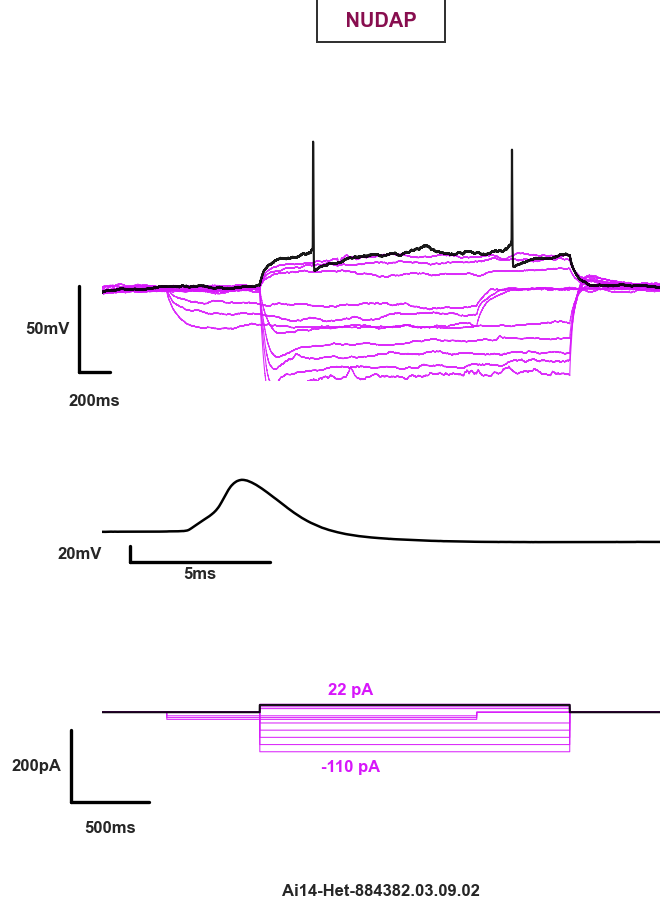

In [33]:
#v2
import os
import re
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import find_peaks

# =========================================================================
# 1. CHOOSE YOUR CELL INDEX TO TEST
# =========================================================================
CELL_INDEX = 38  # <--- Change this to 0, 1, 2, 3, etc.

if CELL_INDEX >= len(df_plot):
    print(f"⚠️ Index {CELL_INDEX} is out of bounds! You have {len(df_plot)} total cells.")
else:
    cell_data = df_plot.iloc[CELL_INDEX]
    cell_name = cell_data['cell_name']
    cohort = cell_data['Cohort']
    nwb_path = os.path.normpath(cell_data['file_path'])
    
    COLORS = {'MSN': '#63C5F7', 'NUDAP': '#D717FA'}
    BOX_TEXT_COLORS = {'MSN': '#1A237E', 'NUDAP': '#880E4F'} 
    
    c_color = COLORS[cohort]
    t_color = BOX_TEXT_COLORS[cohort]

    print("=" * 65)
    print(f"🔬 TESTING CELL {CELL_INDEX}: {cell_name} ({cohort})")
    print(f"📂 Path: {nwb_path}")
    print("=" * 65)

    def draw_l_scalebar(ax, x_len, y_len, x_unit, y_unit, x0, y0, x_text_offset):
        ax.plot([x0, x0], [y0, y0 + y_len], color='black', lw=2.0, clip_on=False)
        ax.plot([x0, x0 + x_len], [y0, y0], color='black', lw=2.0, clip_on=False)
        ax.text(x0 - x_text_offset, y0 + (y_len / 2.0), f"{int(y_len)}{y_unit}", va='center', ha='right', fontsize=10, fontweight='bold')
        ax.text(x0 + (x_len / 2.0), y0 - (y_len * 0.25), f"{int(x_len)}{x_unit}", va='top', ha='center', fontsize=10, fontweight='bold')

    fig = plt.figure(figsize=(6, 8), facecolor='white', dpi=120)
    gs = gridspec.GridSpec(3, 1, height_ratios=[2.5, 1.0, 1.5], hspace=0.35)
    
    ax_v = fig.add_subplot(gs[0])
    ax_zoom = fig.add_subplot(gs[1])
    ax_i = fig.add_subplot(gs[2])
    
    ax_v.text(0.5, 1.20, f"   {cohort}   ", transform=ax_v.transAxes, fontsize=12, fontweight='bold',
              ha='center', va='center', color=t_color,
              bbox=dict(boxstyle='square,pad=0.6', facecolor='white', edgecolor='#333333', lw=1.2))
    
    for ax in [ax_v, ax_zoom, ax_i]:
        ax.axis('off')
        ax.set_facecolor('white')

    if not os.path.exists(nwb_path):
        ax_v.text(0.5, 0.5, "Raw NWB File Not Found", ha='center', va='center', transform=ax_v.transAxes)
    else:
        sweep_family = {}
        
        try:
            with h5py.File(nwb_path, 'r') as f:
                stim_group = f['stimulus/presentation']
                
                def get_sweep_num(k):
                    match = re.search(r'\d+', k)
                    return int(match.group()) if match else -1
                
                stim_keys = sorted([k for k in stim_group.keys() if 'data' in stim_group[k]], key=get_sweep_num)
                
                for key in stim_keys:
                    # 1. READ DESCRIPTION
                    stim_desc = ""
                    if 'stimulus_description' in stim_group[key].attrs:
                        val = stim_group[key].attrs['stimulus_description']
                        stim_desc = val.decode('utf-8', errors='ignore') if isinstance(val, bytes) else str(val)
                    elif 'stimulus_description' in stim_group[key]:
                        val = stim_group[key]['stimulus_description'][()]
                        stim_desc = val.decode('utf-8', errors='ignore') if isinstance(val, bytes) else str(val)
                        
                    desc_lower = stim_desc.lower()
                    
                    # Drop ramps, chirps, noise, and VC
                    if any(x in desc_lower for x in ['ramp', 'chirp', 'zap', 'short', 'sp_', 'noise', 'vc']):
                        continue

                    # 2. DIRECT PATH RESOLUTION
                    v_path = None
                    v_key_1 = key.replace("DA0", "AD0").replace("presentation", "timeseries")
                    match = re.search(r'\d+', key)
                    
                    if f'acquisition/timeseries/{v_key_1}/data' in f:
                        v_path = f'acquisition/timeseries/{v_key_1}/data'
                    elif match and f'acquisition/Sweep_{int(match.group())}/data' in f:
                        v_path = f'acquisition/Sweep_{int(match.group())}/data'
                    elif match and f'acquisition/data_{int(match.group()):05d}_AD0/data' in f:
                        v_path = f'acquisition/data_{int(match.group()):05d}_AD0/data'
                        
                    if not v_path:
                        continue

                    # 3. LOAD DATA & GUARD AGAINST STRING/BYTES DATASETS
                    i_raw = stim_group[f'{key}/data'][:]
                    v_raw = f[v_path][:]
                    
                    if not np.issubdtype(i_raw.dtype, np.number) or not np.issubdtype(v_raw.dtype, np.number):
                        continue
                        
                    i_tr = i_raw.astype(float)
                    v_tr = v_raw.astype(float)

                    if i_tr.ndim > 1: i_tr = i_tr[:, 0]
                    if v_tr.ndim > 1: v_tr = v_tr[:, 0]
                    
                    # Drop NaNs
                    i_tr = i_tr[~np.isnan(i_tr)]
                    v_tr = v_tr[~np.isnan(v_tr)]
                    if len(v_tr) == 0 or len(i_tr) == 0: continue
                    
                    min_len = min(len(i_tr), len(v_tr))
                    i_tr, v_tr = i_tr[:min_len], v_tr[:min_len]

                    # 4. UNITS SCALING
                    max_i = np.max(np.abs(i_tr))
                    if max_i < 1e-6: i_tr = i_tr * 1e12 
                    elif max_i < 1e-3: i_tr = i_tr * 1e9   
                    
                    max_v = np.max(np.abs(v_tr))
                    if max_v < 1.0: v_tr = v_tr * 1000.0 
                        
                    # 5. REJECT UNPHYSIOLOGICAL ARTIFACTS (Drops Sweeps 3-8)
                    if np.max(v_tr) > 100 or np.min(v_tr) < -150:
                        continue
                        
                    t = (np.arange(len(v_tr)) / 25000.0) * 1000.0
                    
                    base_i = np.median(i_tr[:int(len(i_tr)*0.05)])
                    active_idx = np.where(np.abs(i_tr - base_i) > 5.0)[0]
                    
                    # Pulse duration >= 400ms
                    if len(active_idx) < 10000: 
                        continue
                        
                    inj_amp = int(np.round(np.median(i_tr[active_idx]) - base_i))
                    
                    peaks, _ = find_peaks(v_tr, height=-20)
                    
                    # Overwrite earlier aborted runs with clean later sweeps
                    sweep_family[inj_amp] = {
                        'v_tr': v_tr, 'i_tr': i_tr, 't': t,
                        'has_spike': len(peaks) > 0, 'peaks': peaks,
                        'sweep_key': key
                    }

            # =========================================================================
            # 6. RHEOBASE SELECTION & PLOTTING
            # =========================================================================
            if not sweep_family:
                ax_v.text(0.5, 0.5, "No valid sweeps found after filtering.", ha='center', va='center', transform=ax_v.transAxes)
            else:
                spiking_amps = sorted([amp for amp, data in sweep_family.items() if data['has_spike'] and amp > 0])
                
                if not spiking_amps:
                    kept_amps = [amp for amp in sweep_family.keys() if amp <= 0]
                    rheo_amp = None
                else:
                    rheo_amp = spiking_amps[0]
                    pos_amps = sorted([amp for amp in sweep_family.keys() if amp > 0])
                    rheo_idx = pos_amps.index(rheo_amp)
                    max_allowed_amp = pos_amps[rheo_idx + 1] if rheo_idx + 1 < len(pos_amps) else rheo_amp
                    kept_amps = [amp for amp in sweep_family.keys() if amp <= max_allowed_amp]
                
                print(f"👉 Success! Extracted {len(sweep_family)} valid sweeps.")
                print(f"👉 Rheobase identified at: {rheo_amp} pA")
                print(f"👉 Plotting steps: {kept_amps}")
                
                if kept_amps:
                    max_pA = max(kept_amps)
                    min_pA = min([amp for amp in kept_amps if amp < 0] + [0])
                    
                    for amp in kept_amps:
                        data = sweep_family[amp]
                        is_rheo = (amp == rheo_amp)
                        
                        line_color = '#000000' if is_rheo else c_color
                        z_order = 10 if is_rheo else 2
                        l_width = 1.3 if is_rheo else 0.65
                        
                        ax_v.plot(data['t'], data['v_tr'], color=line_color, lw=l_width, zorder=z_order, alpha=0.9)
                        ax_i.plot(data['t'], data['i_tr'], color=line_color, lw=l_width, zorder=z_order, alpha=0.9)
                        
                        if is_rheo and len(data['peaks']) > 0:
                            peak_t = data['t'][data['peaks'][0]]
                            zoom_mask = (data['t'] >= peak_t - 5.0) & (data['t'] <= peak_t + 15.0)
                            ax_zoom.plot(data['t'][zoom_mask] - peak_t, data['v_tr'][zoom_mask], color='#000000', lw=1.5)

                    ax_v.set_xlim(200, 3800)
                    ax_v.set_ylim(-110, 65)
                    draw_l_scalebar(ax_v, x_len=200, y_len=50, x_unit='ms', y_unit='mV', x0=50, y0=-105, x_text_offset=60)

                    ax_zoom.set_xlim(-5, 15)
                    ax_zoom.set_ylim(-80, 65)
                    draw_l_scalebar(ax_zoom, x_len=5, y_len=20, x_unit='ms', y_unit='mV', x0=-4, y0=-70, x_text_offset=1)

                    ax_i.set_xlim(200, 3800)
                    ax_i.set_ylim(-300, max(max_pA + 100, 200))
                    draw_l_scalebar(ax_i, x_len=500, y_len=200, x_unit='ms', y_unit='pA', x0=0, y0=-250, x_text_offset=60)

                    ax_i.text(1800, max_pA + 20, f"{max_pA} pA", ha='center', va='bottom', fontsize=10, fontweight='bold', color=c_color)
                    if min_pA < 0:
                        ax_i.text(1800, min_pA - 20, f"{min_pA} pA", ha='center', va='top', fontsize=10, fontweight='bold', color=c_color)

                    ax_i.text(0.5, -0.35, f"{cell_name}", transform=ax_i.transAxes, fontsize=10, fontweight='bold', ha='center', va='top')

        except Exception as e:
            print(f"⚠️ Error plotting {cell_name}: {e}")

    plt.show()

🔬 TESTING CELL 38: Ai14-Het-884382.03.09.02 (NUDAP)


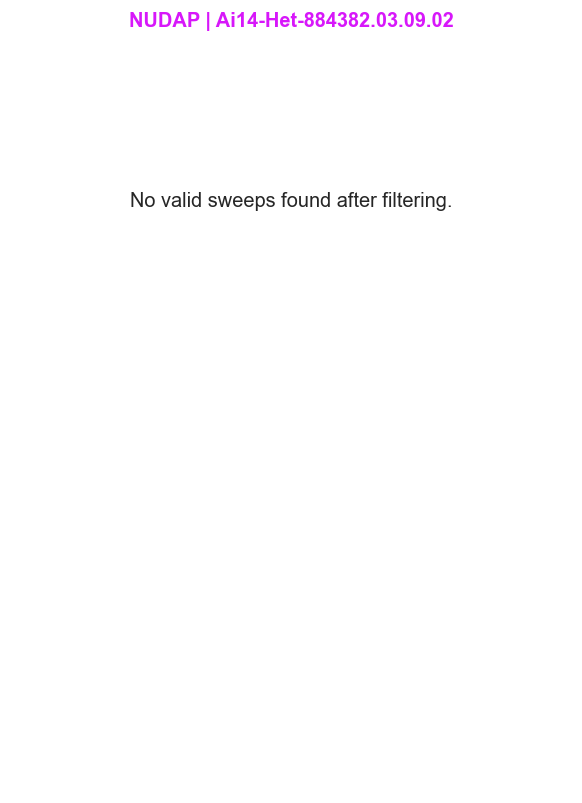

In [22]:
import os
import re
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import find_peaks

# =========================================================================
# 1. CHOOSE YOUR CELL TO TEST
# =========================================================================
CELL_INDEX = 38  # Testing Ai14-Het-884382.03.09.02

if CELL_INDEX >= len(df_plot):
    print(f"⚠️ Index {CELL_INDEX} is out of bounds!")
else:
    cell_data = df_plot.iloc[CELL_INDEX]
    cell_name = cell_data['cell_name']
    cohort = cell_data['Cohort']
    nwb_path = os.path.normpath(cell_data['file_path'])
    
    COLORS = {'MSN': '#63C5F7', 'NUDAP': '#D717FA'}
    c_color = COLORS[cohort]

    print("=" * 60)
    print(f"🔬 TESTING CELL {CELL_INDEX}: {cell_name} ({cohort})")
    print("=" * 60)

    def draw_l_scalebar(ax, x_len, y_len, x_unit, y_unit, x0, y0, x_text_offset):
        ax.plot([x0, x0], [y0, y0 + y_len], color='black', lw=2.0, clip_on=False)
        ax.plot([x0, x0 + x_len], [y0, y0], color='black', lw=2.0, clip_on=False)
        ax.text(x0 - x_text_offset, y0 + (y_len / 2.0), f"{int(y_len)}{y_unit}", va='center', ha='right', fontsize=10, fontweight='bold')
        ax.text(x0 + (x_len / 2.0), y0 - (y_len * 0.25), f"{int(x_len)}{x_unit}", va='top', ha='center', fontsize=10, fontweight='bold')

    fig = plt.figure(figsize=(6, 8), facecolor='white', dpi=120)
    gs = gridspec.GridSpec(3, 1, height_ratios=[2.5, 1.0, 1.5], hspace=0.35)
    
    ax_v = fig.add_subplot(gs[0])
    ax_zoom = fig.add_subplot(gs[1])
    ax_i = fig.add_subplot(gs[2])
    
    ax_v.set_title(f"{cohort} | {cell_name}", color=c_color, fontweight='bold', pad=15)
    
    for ax in [ax_v, ax_zoom, ax_i]:
        ax.axis('off')
        ax.set_facecolor('white')

    if not os.path.exists(nwb_path):
        ax_v.text(0.5, 0.5, "Raw NWB File Not Found", ha='center', va='center')
    else:
        sweep_family = {}
        
        try:
            with h5py.File(nwb_path, 'r') as f:
                stim_group = f['stimulus/presentation']
                def get_sweep_num(k):
                    match = re.search(r'\d+', k)
                    return int(match.group()) if match else -1
                stim_keys = sorted([k for k in stim_group.keys() if 'data' in stim_group[k]], key=get_sweep_num)
                
                # --- BULLETPROOF VOLTAGE PATH FINDER ---
                # Pre-map all voltage arrays in the file
                acq_paths = {}
                def find_acq_paths(name, obj):
                    if isinstance(obj, h5py.Dataset):
                        # Use the immediate folder/dataset name as the key (e.g., 'data_00042_AD0')
                        folder_name = name.split('/')[-2] if len(name.split('/')) > 1 else name.split('/')[0]
                        acq_paths[folder_name] = f'acquisition/{name}'
                
                if 'acquisition' in f:
                    f['acquisition'].visititems(find_acq_paths)
                
                for key in stim_keys:
                    stim_desc = ""
                    if 'stimulus_description' in stim_group[key].attrs:
                        val = stim_group[key].attrs['stimulus_description']
                        stim_desc = val.decode('utf-8') if isinstance(val, bytes) else str(val)
                    elif 'stimulus_description' in stim_group[key]:
                        val = stim_group[key]['stimulus_description'][()]
                        stim_desc = val.decode('utf-8') if isinstance(val, bytes) else str(val)
                        
                    desc_lower = stim_desc.lower()
                    
                    if not any(x in desc_lower for x in ['if_step', 'square', 'fi', 'vi', 'long', 'subthresh', 'rheo', 'suprathresh']):
                        continue
                    if any(x in desc_lower for x in ['ramp', 'chirp', 'zap', 'short', 'sp_', 'noise', 'vc']):
                        continue

                    # Dynamic Path Resolution
                    v_path = None
                    
                    # 1. Look for matching AD0 key in our mapped paths
                    v_target_key = key.split('/')[-1].replace('DA0', 'AD0')
                    if v_target_key in acq_paths:
                        v_path = acq_paths[v_target_key]
                    
                    # 2. Fallback to Sweep_XXXXX logic
                    if not v_path:
                        match = re.search(r'\d+', key)
                        if match and f'Sweep_{int(match.group())}' in acq_paths:
                            v_path = acq_paths[f'Sweep_{int(match.group())}']
                            
                    if not v_path or v_path not in f:
                        continue

                    i_tr = stim_group[f'{key}/data'][:]
                    v_tr = f[v_path][:]
                    if i_tr.ndim > 1: i_tr = i_tr[:, 0]
                    if v_tr.ndim > 1: v_tr = v_tr[:, 0]
                    
                    max_i = np.max(np.abs(i_tr))
                    if max_i < 1e-6: i_tr = i_tr * 1e12 
                    elif max_i < 1e-3: i_tr = i_tr * 1e9   
                    
                    if np.max(np.abs(v_tr)) < 1.0:
                        v_tr = v_tr * 1000.0 
                        
                    if np.max(v_tr) > 100 or np.min(v_tr) < -150:
                        continue
                        
                    t = (np.arange(len(v_tr)) / 25000.0) * 1000.0
                    
                    base_i = np.median(i_tr[:int(len(i_tr)*0.05)])
                    active_idx = np.where(np.abs(i_tr - base_i) > 5.0)[0]
                    
                    if len(active_idx) < 10000: 
                        continue
                        
                    inj_amp = int(np.round(np.median(i_tr[active_idx]) - base_i))
                    
                    peaks, _ = find_peaks(v_tr, height=-20)
                    sweep_family[inj_amp] = {
                        'v_tr': v_tr, 'i_tr': i_tr, 't': t,
                        'has_spike': len(peaks) > 0, 'peaks': peaks,
                        'desc': stim_desc,
                        'sweep_key': key
                    }

            if not sweep_family:
                ax_v.text(0.5, 0.5, "No valid sweeps found after filtering.", ha='center', va='center')
            else:
                spiking_amps = sorted([amp for amp, data in sweep_family.items() if data['has_spike'] and amp > 0])
                
                if not spiking_amps:
                    kept_amps = [amp for amp in sweep_family.keys() if amp <= 0]
                    rheo_amp = None
                else:
                    rheo_amp = spiking_amps[0]
                    pos_amps = sorted([amp for amp in sweep_family.keys() if amp > 0])
                    rheo_idx = pos_amps.index(rheo_amp)
                    max_allowed_amp = pos_amps[rheo_idx + 1] if rheo_idx + 1 < len(pos_amps) else rheo_amp
                    kept_amps = [amp for amp in sweep_family.keys() if amp <= max_allowed_amp]
                
                print(f"👉 Success! Plotting {len(kept_amps)} clean sweeps:")
                
                if kept_amps:
                    max_pA = max(kept_amps)
                    min_pA = min([amp for amp in kept_amps if amp < 0] + [0])
                    
                    for amp in kept_amps:
                        data = sweep_family[amp]
                        is_rheo = (amp == rheo_amp)
                        
                        line_color = '#000000' if is_rheo else c_color
                        z_order = 10 if is_rheo else 2
                        l_width = 1.3 if is_rheo else 0.65
                        
                        ax_v.plot(data['t'], data['v_tr'], color=line_color, lw=l_width, zorder=z_order, alpha=0.9)
                        ax_i.plot(data['t'], data['i_tr'], color=line_color, lw=l_width, zorder=z_order, alpha=0.9)
                        
                        if is_rheo and len(data['peaks']) > 0:
                            peak_t = data['t'][data['peaks'][0]]
                            zoom_mask = (data['t'] >= peak_t - 5.0) & (data['t'] <= peak_t + 15.0)
                            ax_zoom.plot(data['t'][zoom_mask] - peak_t, data['v_tr'][zoom_mask], color='#000000', lw=1.5)

                    ax_v.set_xlim(200, 3800)
                    ax_v.set_ylim(-110, 65)
                    draw_l_scalebar(ax_v, x_len=200, y_len=50, x_unit='ms', y_unit='mV', x0=50, y0=-105, x_text_offset=60)

                    ax_zoom.set_xlim(-5, 15)
                    ax_zoom.set_ylim(-80, 65)
                    draw_l_scalebar(ax_zoom, x_len=5, y_len=20, x_unit='ms', y_unit='mV', x0=-4, y0=-70, x_text_offset=1)

                    ax_i.set_xlim(200, 3800)
                    ax_i.set_ylim(-300, max(max_pA + 100, 200))
                    draw_l_scalebar(ax_i, x_len=500, y_len=200, x_unit='ms', y_unit='pA', x0=0, y0=-250, x_text_offset=60)

                    ax_i.text(1800, max_pA + 20, f"{max_pA} pA", ha='center', va='bottom', fontsize=10, fontweight='bold', color=c_color)
                    if min_pA < 0:
                        ax_i.text(1800, min_pA - 20, f"{min_pA} pA", ha='center', va='top', fontsize=10, fontweight='bold', color=c_color)

        except Exception as e:
            print(f"⚠️ Error plotting {cell_name}: {e}")

    plt.show()

## 5c. finding data path

In [21]:
import os
import h5py

# =========================================================================
# CHOOSE THE BROKEN CELL
# =========================================================================
CELL_INDEX = 38  # Testing Ai14-Het-884382.03.09.02

if CELL_INDEX >= len(df_plot):
    print("Index out of bounds")
else:
    cell_data = df_plot.iloc[CELL_INDEX]
    nwb_path = os.path.normpath(cell_data['file_path'])
    
    print("=" * 80)
    print(f"🔍 SCANNING NWB FILE: {cell_data['cell_name']}")
    print(f"📂 Path: {nwb_path}")
    print("=" * 80)

    def print_hdf5_structure(name, obj):
        # We only care about finding where 'data' arrays live
        if isinstance(obj, h5py.Dataset):
            # Print the path and the shape of the data
            if len(obj.shape) > 0 and obj.shape[0] > 1000:
                print(f"Dataset found: {name} | Shape: {obj.shape}")

    if not os.path.exists(nwb_path):
        print("File not found on disk!")
    else:
        try:
            with h5py.File(nwb_path, 'r') as f:
                print("\n--- ACQUISITION FOLDER (Looking for Voltage) ---")
                if 'acquisition' in f:
                    f['acquisition'].visititems(print_hdf5_structure)
                else:
                    print("No 'acquisition' folder found at all!")
                    
                print("\n--- STIMULUS FOLDER (Looking for Current) ---")
                if 'stimulus' in f:
                    f['stimulus'].visititems(print_hdf5_structure)
                else:
                    print("No 'stimulus' folder found!")
                    
        except Exception as e:
            print(f"Failed to read file: {e}")

🔍 SCANNING NWB FILE: Ai14-Het-884382.03.09.02
📂 Path: \\allen\programs\celltypes\workgroups\hct\SamanthaL\Ephys recordings\Mouse striatum cell types\Ai14-Het-884382.03.09.02.nwb

--- ACQUISITION FOLDER (Looking for Voltage) ---
Dataset found: data_00000_AD0/data | Shape: (160999,)
Dataset found: data_00001_AD0/data | Shape: (160999,)
Dataset found: data_00002_AD0/data | Shape: (12296999,)
Dataset found: data_00003_AD0/data | Shape: (12296999,)
Dataset found: data_00004_AD0/data | Shape: (160999,)
Dataset found: data_00005_AD0/data | Shape: (305410,)
Dataset found: data_00006_AD0/data | Shape: (180410,)
Dataset found: data_00007_AD0/data | Shape: (180410,)
Dataset found: data_00008_AD0/data | Shape: (180410,)
Dataset found: data_00009_AD0/data | Shape: (180410,)
Dataset found: data_00010_AD0/data | Shape: (180410,)
Dataset found: data_00011_AD0/data | Shape: (180410,)
Dataset found: data_00012_AD0/data | Shape: (180410,)
Dataset found: data_00013_AD0/data | Shape: (180410,)
Dataset foun

🕵️ NWB DATA DISCOVERY TOOL
File: \\allen\programs\celltypes\workgroups\hct\SamanthaL\Ephys recordings\Mouse striatum cell types\Ai14-Het-884382.03.09.02.nwb

--- ⚡ VOLTAGE (AD0) ---
Path: acquisition/data_00042_AD0/data
Attributes: {'IGORWaveType': '2', 'IGORWaveScaling': '[[0.   0.  ]\n [0.02 0.  ]]', 'IGORWaveUnits': "['mV' 'ms']", 'IGORWaveNote': "b'WAVE_LAYOUT_VERSION:1;\\rHS#0:Set Sweep Count: 0.00 \\rTP Insert Checkbox: On\\rInter-trial interval: 5.00 s\\rDelay onset auto: 108.22 ms\\rHS#0:Stim set length: 274999.00 \\rHS#0:Stim Wave Checksum: 1138709212.00 \\rTP during ITI: On\\rHS#0:Stimset Acq Cycle ID: 5473478.00 \\rHS#0:USER_Rheobase version: 6.00 \\rHS#0:USER_Rheobase Pulse duration: On\\rHS#0:USER_Rheobase BL QC: On\\rHS#0:USER_Rheobase S-RMS Threshold: On\\rHS#0:USER_Rheobase L-RMS Threshold: On\\rHS#0:USER_Rheobase T-V Threshold: On\\rHS#0:USER_Rheobase Chk0 S-RMS: On\\rHS#0:USER_Rheobase Chk0 L-RMS: On\\rHS#0:USER_Rheobase Chk0 S-RMS QC: On\\rHS#0:USER_Rheobase Chk0 L-R

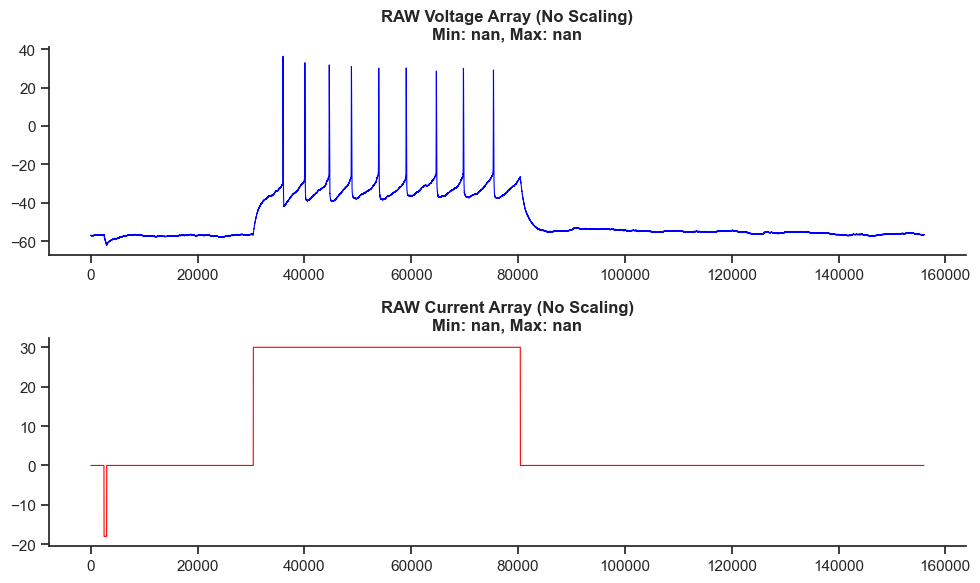

In [25]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# =========================================================================
# CHOOSE THE BROKEN CELL
# =========================================================================
CELL_INDEX = 38  # Testing Ai14-Het-884382.03.09.02

cell_data = df_plot.iloc[CELL_INDEX]
nwb_path = os.path.normpath(cell_data['file_path'])

print("=" * 80)
print("🕵️ NWB DATA DISCOVERY TOOL")
print(f"File: {nwb_path}")
print("=" * 80)

try:
    with h5py.File(nwb_path, 'r') as f:
        # We know Sweep 42 exists from our previous directory scan
        v_path = 'acquisition/data_00042_AD0/data'
        i_path = 'stimulus/presentation/data_00042_DA0/data'
        
        # --- 1. INSPECT VOLTAGE ---
        print("\n--- ⚡ VOLTAGE (AD0) ---")
        if v_path in f:
            v_ds = f[v_path]
            print(f"Path: {v_path}")
            
            # Print all hidden attributes (looking for 'conversion', 'unit', 'multiplier')
            attrs_dict = {k: str(v) for k, v in v_ds.attrs.items()}
            print(f"Attributes: {attrs_dict}")
            
            v_raw = v_ds[:].astype(float)
            if v_raw.ndim > 1: v_raw = v_raw[:, 0]
            print(f"Raw Data -> Min: {np.min(v_raw):.6f} | Max: {np.max(v_raw):.6f} | Mean: {np.mean(v_raw):.6f}")
        else:
            print("Voltage path not found.")
            
        # --- 2. INSPECT CURRENT ---
        print("\n--- 🔋 CURRENT (DA0) ---")
        if i_path in f:
            i_ds = f[i_path]
            print(f"Path: {i_path}")
            
            attrs_dict = {k: str(v) for k, v in i_ds.attrs.items()}
            print(f"Attributes: {attrs_dict}")
            
            i_raw = i_ds[:].astype(float)
            if i_raw.ndim > 1: i_raw = i_raw[:, 0]
            print(f"Raw Data -> Min: {np.min(i_raw):.6f} | Max: {np.max(i_raw):.6f} | Mean: {np.mean(i_raw):.6f}")
        else:
            print("Current path not found.")

        # --- 3. RAW UNSCALED PLOT ---
        if v_path in f and i_path in f:
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), facecolor='white')
            
            ax1.plot(v_raw, color='blue', lw=0.8)
            ax1.set_title(f"RAW Voltage Array (No Scaling)\nMin: {np.min(v_raw):.4f}, Max: {np.max(v_raw):.4f}", fontweight='bold')
            ax1.spines['top'].set_visible(False)
            ax1.spines['right'].set_visible(False)
            
            ax2.plot(i_raw, color='red', lw=0.8)
            ax2.set_title(f"RAW Current Array (No Scaling)\nMin: {np.min(i_raw):.4f}, Max: {np.max(i_raw):.4f}", fontweight='bold')
            ax2.spines['top'].set_visible(False)
            ax2.spines['right'].set_visible(False)
            
            plt.tight_layout()
            plt.show()

except Exception as e:
    print(f"Error: {e}")